In [5]:
import json
import NetworkToolkit as nt

db = "Topology_Data"
collection = "topology-paper"   # NSFNET 通常在这里
topology_name = "NSFNET"
span_length_km = 80

graph_list = nt.Database.read_topology_dataset_list(
    db, collection, find_dic={"name": topology_name}, node_data=True, max_count=1
)

if not graph_list:
    raise RuntimeError(f"{topology_name} not found in {db}.{collection}")

graph, _id = graph_list[0]

data = {
    "name": topology_name,
    "mongo_id": str(_id),
    "span_length_km": span_length_km,
    "nodes": sorted([int(n) for n in graph.nodes()]),
    "links": []
}

for u, v in graph.edges():
    spans = int(graph[u][v].get("weight", 1))
    data["links"].append({"u": int(u), "v": int(v), "spans": spans})

with open("nsfnet_topology_spans_878.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

print("Saved: nsfnet_topology_spans.json")
print(f"nodes={len(data['nodes'])}, links={len(data['links'])}")

reading data in topology-paper: 1it [00:31, 31.80s/it]

Saved: nsfnet_topology_spans.json
nodes=14, links=21


In [58]:
import NetworkToolkit as nt
import ast
import json
from pathlib import Path

# === Config ===
db_name = "Topology_Data"
collection_name = "real"
topology_name = "BT22"
rwa_key = "kSP-FF OESCL RWA"
out_dir = Path(".")

# Read all docs for the topology (usually one, but keep it generic)
results = list(
    nt.Database.read_data(
        db_name,
        collection_name,
        find_dic={"name": topology_name},
        max_count=100,
    )
)

print(f"Found {len(results)} document(s) for topology '{topology_name}' in {db_name}.{collection_name}")
print(f"Target RWA key: {rwa_key}\n")

if len(results) == 0:
    print("No matching topology document found.")

for i, result in enumerate(results, 1):
    print("=" * 70)
    print(f"Document #{i}")
    _id = str(result.get("_id"))
    print(f"_id: {_id}")

    if rwa_key not in result:
        rwa_like_keys = [k for k in result.keys() if "RWA" in str(k)]
        print(f"[MISSING] key '{rwa_key}' not found.")
        print(f"Available RWA-like keys ({len(rwa_like_keys)}):")
        for k in sorted(rwa_like_keys):
            print(f"  - {k}")
        continue

    rwa_raw = result[rwa_key]
    if isinstance(rwa_raw, str):
        rwa_raw = ast.literal_eval(rwa_raw)

    rwa = nt.Tools.read_database_dict(rwa_raw)

    used_wavelengths = [w for w, paths in rwa.items() if paths]
    total_lightpaths = sum(len(paths) for paths in rwa.values())

    print("[FOUND] RWA key exists.")
    print(f"Used wavelengths: {len(used_wavelengths)}")
    print(f"Total lightpaths: {total_lightpaths}")

    # Save read RWA to JSON for later use.
    save_name = f"rwa_{topology_name}_{rwa_key.replace(' ', '_')}_{_id}.json"
    save_path = out_dir / save_name
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(rwa, f, ensure_ascii=False)
    print(f"Saved RWA JSON: {save_path}")

    # Preview first few wavelengths
    preview = used_wavelengths[:10]
    print(f"First used wavelengths (up to 10): {preview}")


Found 1 document(s) for topology 'BT22' in Topology_Data.real
Target RWA key: kSP-FF OESCL RWA

Document #1
_id: 69e242d0a05a760ab5de14c3
[FOUND] RWA key exists.
Used wavelengths: 878
Total lightpaths: 5685
Saved RWA JSON: rwa_BT22_kSP-FF_OESCL_RWA_69e242d0a05a760ab5de14c3.json
First used wavelengths (up to 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [59]:
import NetworkToolkit as nt
from bson import json_util

# === Config ===
db_name = "Topology_Data"
collection_name = "real"  # 或 "real"
topology_name = "LondonDCI"
# LondonDCI
results = list(
    nt.Database.read_data(
        db_name,
        collection_name,
        find_dic={"name": topology_name},
        max_count=100,
    )
)

print(f"Found {len(results)} document(s) for name={topology_name!r} in {db_name}.{collection_name}\n")

if not results:
    print("No matching topology document found.")
else:
    for i, doc in enumerate(results, 1):
        print("=" * 70)
        print(f"Document #{i}  _id={doc.get('_id')}")
        print("=" * 70)
        # 整条文档（含 topology data、node data、各类 RWA 键等）
        print(json_util.dumps(doc, indent=2, ensure_ascii=False))
        print()

Found 1 document(s) for name='LondonDCI' in Topology_Data.real

Document #1  _id=69c92385e8da37637e38d479
{
  "_id": {
    "$oid": "69c92385e8da37637e38d479"
  },
  "connectivity": 0.2948717948717949,
  "topology vector": 0,
  "D FF_kSP": 0,
  "D ILP": 0,
  "D upper bound": 0,
  "D lower bound": 0,
  "algebraic connectivity": 0,
  "cheeger constant": 0,
  "total network capacity ILP": 0,
  "total network capacity FF_kSP": 0,
  "chromatic number": 0,
  "RWA density ILP": 0,
  "RWA density FF_kSP": 0,
  "h": 0,
  "topology data": {
    "1": {
      "2": "{'weight': 1, 'length_km': 5.3304, 'span_length_km': 5.3304}",
      "8": "{'weight': 1, 'length_km': 1.7756, 'span_length_km': 1.7756}",
      "9": "{'weight': 1, 'length_km': 6.4632, 'span_length_km': 6.4632}",
      "13": "{'weight': 1, 'length_km': 15.7234, 'span_length_km': 15.7234}"
    },
    "2": {
      "1": "{'weight': 1, 'length_km': 5.3304, 'span_length_km': 5.3304}",
      "4": "{'weight': 1, 'length_km': 21.4801, 'span_leng

In [54]:
"""
Fix LondonDCI edge lengths in MongoDB.

The topology was stored with all length_km=80 and span_length_km=80,
but the actual haversine distances between nodes are 1–28 km.

This script:
  1. Reads the LondonDCI document from Topology_Data.real
  2. Recalculates length_km and span_length_km from node lat/lon (haversine)
  3. Keeps weight=1 (one span per link, used as hop count for routing)
  4. Writes the corrected topology_data back to MongoDB

Run:
    python fix_london_dci_lengths.py [--host HOST] [--port PORT]
                                     [--user USER] [--password PWD]
                                     [--dry-run]
"""

import argparse
import ast
import math
from bson import ObjectId
from pymongo import MongoClient

# ── document coordinates ────────────────────────────────────────────────────
DB         = "Topology_Data"
COLLECTION = "real"
DOC_ID     = ObjectId("69c92385e8da37637e38d479")

EARTH_R_KM = 6371.0


def haversine_km(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlam / 2) ** 2
    return EARTH_R_KM * 2 * math.asin(math.sqrt(a))


def build_corrected_topology_data(topology_data: dict, node_data: dict) -> dict:
    """Return a new topology_data dict with corrected length_km / span_length_km."""
    corrected = {}
    for src, neighbours in topology_data.items():
        corrected[src] = {}
        lat1 = float(node_data[src]["latitude"])
        lon1 = float(node_data[src]["longitude"])
        for dst, edge_str in neighbours.items():
            lat2 = float(node_data[dst]["latitude"])
            lon2 = float(node_data[dst]["longitude"])
            dist_km = round(haversine_km(lat1, lon1, lat2, lon2), 4)

            edge_dict = ast.literal_eval(edge_str)
            edge_dict["length_km"]      = dist_km
            edge_dict["span_length_km"] = dist_km  # one span per link
            # weight stays 1 (hop count used by kSP routing)
            corrected[src][dst] = str(edge_dict)
    return corrected


def main():
    parser = argparse.ArgumentParser(description="Fix LondonDCI edge lengths")
    parser.add_argument("--host",     default="localhost")
    parser.add_argument("--port",     default=27017, type=int)
    parser.add_argument("--user",     default=None)
    parser.add_argument("--password", default=None)
    parser.add_argument("--dry-run",  action="store_true",
                        help="Print changes without writing to MongoDB")
    args, _ = parser.parse_known_args()

    # ── connect ──────────────────────────────────────────────────────────────
    if args.user and args.password:
        uri = f"mongodb://{args.user}:{args.password}@{args.host}:{args.port}/"
    else:
        uri = f"mongodb://{args.host}:{args.port}/"
    client = MongoClient(uri)
    col = client[DB][COLLECTION]

    # ── fetch document ────────────────────────────────────────────────────────
    doc = col.find_one({"_id": DOC_ID})
    if doc is None:
        raise RuntimeError(f"Document {DOC_ID} not found in {DB}.{COLLECTION}")
    print(f"Found document: name='{doc.get('name')}', _id={doc['_id']}")

    topology_data = doc["topology data"]
    node_data     = doc["node data"]

    # ── compute corrected edges ───────────────────────────────────────────────
    corrected = build_corrected_topology_data(topology_data, node_data)

    # ── print diff ────────────────────────────────────────────────────────────
    print(f"\n{'Edge':<10} {'Old length_km':>14} {'New length_km':>14}")
    print("-" * 42)
    seen = set()
    for src, neighbours in corrected.items():
        for dst, edge_str in neighbours.items():
            key = (min(src, dst), max(src, dst))
            if key in seen:
                continue
            seen.add(key)
            new_dist = ast.literal_eval(edge_str)["length_km"]
            old_dist = ast.literal_eval(topology_data[src][dst])["length_km"]
            marker = " ✓" if abs(new_dist - old_dist) < 0.01 else " ← CHANGED"
            print(f"({src:>2},{dst:>2})    {old_dist:>14}  {new_dist:>12.4f}{marker}")

    if args.dry_run:
        print("\n[dry-run] No changes written to MongoDB.")
        return

    # ── write back ────────────────────────────────────────────────────────────
    result = col.update_one(
        {"_id": DOC_ID},
        {"$set": {"topology data": corrected}},
    )
    print(f"\nMongoDB update: matched={result.matched_count}, "
          f"modified={result.modified_count}")
    print("Done. topology_data.length_km and span_length_km updated "
          "to haversine distances.")
    client.close()


if __name__ == "__main__":
    main()


Found document: name='LondonDCI', _id=69c92385e8da37637e38d479

Edge        Old length_km  New length_km
------------------------------------------
( 1, 2)                80        5.3304 ← CHANGED
( 1, 8)                80        1.7756 ← CHANGED
( 1, 9)                80        6.4632 ← CHANGED
( 1,13)                80       15.7234 ← CHANGED
( 2, 4)                80       21.4801 ← CHANGED
( 2, 8)                80        6.3263 ← CHANGED
( 2, 9)                80        1.3096 ← CHANGED
( 2,10)                80       24.2447 ← CHANGED
( 2,11)                80       25.3132 ← CHANGED
( 3, 4)                80       15.2640 ← CHANGED
( 3, 5)                80       15.2182 ← CHANGED
( 3, 7)                80       16.2132 ← CHANGED
( 3,10)                80       12.5051 ← CHANGED
( 3,12)                80       22.4113 ← CHANGED
( 4, 5)                80       27.5156 ← CHANGED
( 4, 7)                80        4.4478 ← CHANGED
( 4,10)                80        2.7682 ← CHANGED
( 

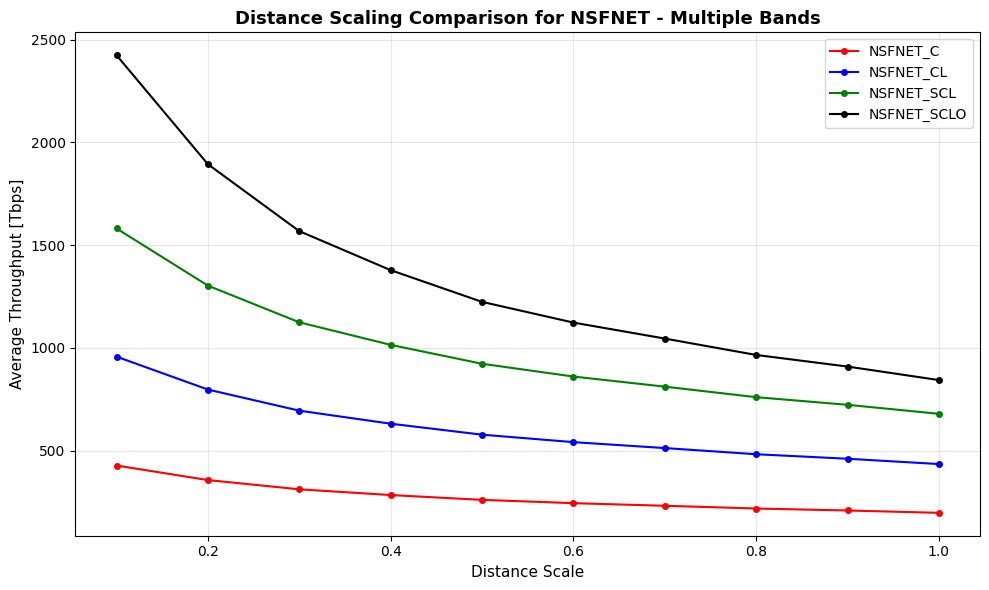

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Plot distance-scaling throughput for NSFNET across bands
# ------------------------------------------------------------
base_dir = Path(".")
band_files = {
    "C": "cfm_scaling_NSFNET_C.csv",
    "CL": "cfm_scaling_NSFNET_CL.csv",
    "SCL": "cfm_scaling_NSFNET_SCL.csv",
    "SCLO": "cfm_scaling_NSFNET_SCLO.csv",
}

colors = {
    "C": "red",
    "CL": "blue",
    "SCL": "green",
    "SCLO": "black",
}

plt.figure(figsize=(10, 6))

for band, filename in band_files.items():
    csv_path = base_dir / filename
    if not csv_path.exists():
        print(f"[WARN] Missing file: {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    required_cols = {"scale", "cfm_capacity_tbps"}
    if not required_cols.issubset(df.columns):
        print(f"[WARN] Missing required columns in {filename}: {required_cols}")
        continue

    # In case multiple rows exist for the same scale, use average throughput.
    df_plot = (
        df.groupby("scale", as_index=False)["cfm_capacity_tbps"]
        .mean()
        .sort_values("scale")
    )

    plt.plot(
        df_plot["scale"],
        df_plot["cfm_capacity_tbps"],
        marker="o",
        linewidth=1.5,
        markersize=4,
        color=colors[band],
        label=f"NSFNET_{band}",
    )

plt.title("Distance Scaling Comparison for NSFNET - Multiple Bands", fontsize=13, weight="bold")
plt.xlabel("Distance Scale", fontsize=11)
plt.ylabel("Average Throughput [Tbps]", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


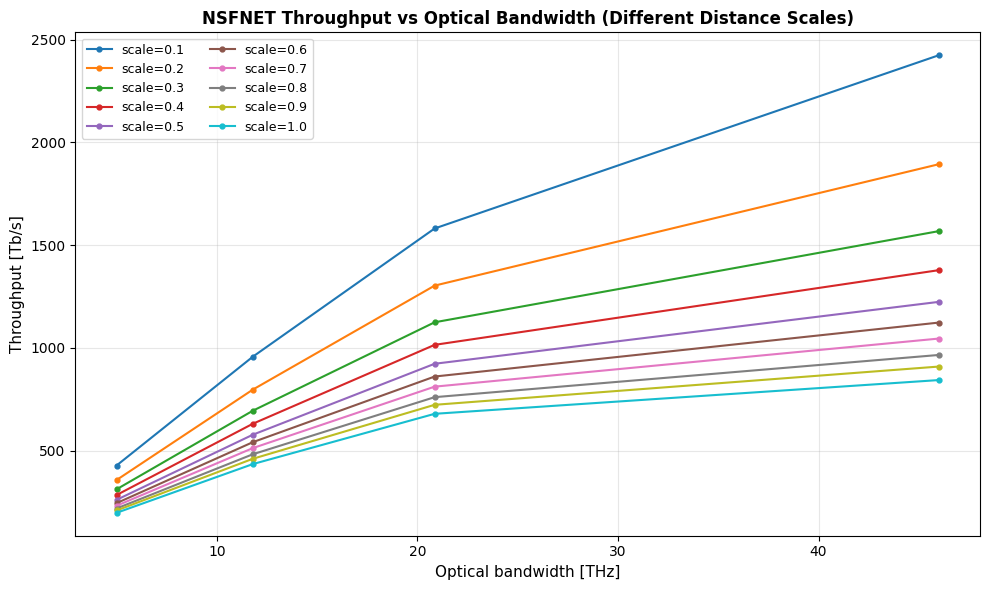

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Plot throughput vs optical bandwidth (THz)
# One curve per distance scale, using C/CL/SCL/SCLO results
# ------------------------------------------------------------
base_dir = Path(".")

# Bandwidth values from band configuration in code
band_to_bw_thz = {
    "C": 5.0,
    "CL": 11.8,
    "SCL": 20.86,
    "SCLO": 46.0,
}

band_files = {
    "C": "cfm_scaling_NSFNET_C.csv",
    "CL": "cfm_scaling_NSFNET_CL.csv",
    "SCL": "cfm_scaling_NSFNET_SCL.csv",
    "SCLO": "cfm_scaling_NSFNET_SCLO.csv",
}

# Read and aggregate each band CSV
band_df = {}
for band, filename in band_files.items():
    csv_path = base_dir / filename
    if not csv_path.exists():
        print(f"[WARN] Missing file: {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    required_cols = {"scale", "cfm_capacity_tbps"}
    if not required_cols.issubset(df.columns):
        print(f"[WARN] Missing required columns in {filename}: {required_cols}")
        continue

    # Average if duplicate scale rows exist
    band_df[band] = (
        df.groupby("scale", as_index=False)["cfm_capacity_tbps"]
        .mean()
        .sort_values("scale")
    )

available_bands = [b for b in ["C", "CL", "SCL", "SCLO"] if b in band_df]
if len(available_bands) < 2:
    raise RuntimeError("Need at least two band CSVs to plot scaling curves.")

# Use intersection of scales so each curve has all bands
scale_sets = [set(df["scale"].round(6).tolist()) for df in band_df.values()]
common_scales = sorted(list(set.intersection(*scale_sets)))
if not common_scales:
    raise RuntimeError("No common scales found across band CSV files.")

plt.figure(figsize=(10, 6))

for scale in common_scales:
    x_vals = []
    y_vals = []
    for band in available_bands:
        row = band_df[band].loc[(band_df[band]["scale"].round(6) == round(scale, 6))]
        if row.empty:
            continue
        x_vals.append(band_to_bw_thz[band])
        y_vals.append(float(row["cfm_capacity_tbps"].iloc[0]))

    if len(x_vals) >= 2:
        plt.plot(
            x_vals,
            y_vals,
            marker="o",
            linewidth=1.5,
            markersize=3.5,
            label=f"scale={scale:.1f}",
        )

plt.title("NSFNET Throughput vs Optical Bandwidth (Different Distance Scales)", fontsize=12, weight="bold")
plt.xlabel("Optical bandwidth [THz]", fontsize=11)
plt.ylabel("Throughput [Tb/s]", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9, frameon=True)
plt.tight_layout()
plt.show()


# delete topo

In [57]:
import NetworkToolkit as nt
from bson import ObjectId

db_name = "Topology_Data"
collection_name = "real"
topology_id = ObjectId("69e24f4da05a760ab5de14ce")

client = nt.Database._mongo_client()
collection = client[db_name][collection_name]
result = collection.delete_one({"_id": topology_id})
client.close()

print(f"deleted_count={result.deleted_count}")
if result.deleted_count == 1:
    print("Deleted Topology_Data.real document:", topology_id)
else:
    print("No document matched _id:", topology_id)


deleted_count=1
Deleted Topology_Data.real document: 69e24f4da05a760ab5de14ce


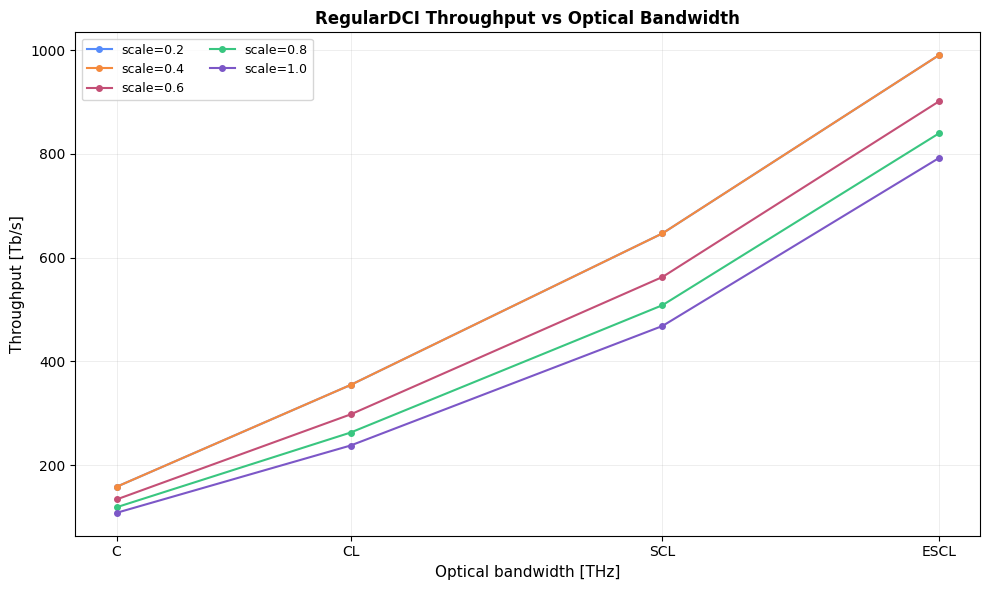

Workbook: /home/uceebd1/pycharm_projects/network_simulations/thesis/throughput_upperbound/simulations/data/scaling_summary.xlsx
Topology: RegularDCI
Band columns used: ['C', 'CL', 'SCL', 'ESCL']
Scales plotted: [0.2, 0.4, 0.6, 0.8, 1.0]


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Plot throughput vs optical bandwidth from scaling_summary.xlsx
# Edit `topology_name` in PyCharm and re-run this cell.
# One curve per scale.
# ------------------------------------------------------------
candidate_paths = [
    Path("data") / "scaling_summary.xlsx",
    Path("thesis/throughput_upperbound/simulations/data") / "scaling_summary.xlsx",
    Path.cwd() / "data" / "scaling_summary.xlsx",
    Path.cwd() / "thesis/throughput_upperbound/simulations/data" / "scaling_summary.xlsx",
]

xlsx_path = next((p.resolve() for p in candidate_paths if p.exists()), None)

topology_name = "RegularDCI"
#CORONET_CONUS_Topology_nodes JPN25 DTAG germany50 nobel-eu RegularDCI NSFNET cost266

route_function_name = None  # e.g. "kSP-FF", or None to keep all

# Optical bandwidth values [THz]
band_to_bw_thz = {
    "C": 5.0,
    "CL": 11.8,
    "SCL": 20.86,
    "ESCL": 28.89,
}

if xlsx_path is None:
    raise FileNotFoundError(
        "Could not find scaling_summary.xlsx. Tried: "
        + ", ".join(str(p) for p in candidate_paths)
    )

df = pd.read_excel(xlsx_path)
required_cols = {"topology", "scale"}
if not required_cols.issubset(df.columns):
    raise RuntimeError(
        f"Workbook must contain columns {required_cols}; got {list(df.columns)}"
    )

available_topologies = sorted(df["topology"].dropna().astype(str).unique().tolist())
if topology_name not in available_topologies:
    raise RuntimeError(
        f"Topology '{topology_name}' not found. Available: {available_topologies}"
    )

plot_df = df[df["topology"].astype(str) == topology_name].copy()
if route_function_name is not None and "route_function" in plot_df.columns:
    plot_df = plot_df[plot_df["route_function"].astype(str) == route_function_name].copy()

if plot_df.empty:
    raise RuntimeError(
        f"No rows left after filtering for topology={topology_name!r}, route_function={route_function_name!r}"
    )

band_columns = [b for b in ["C", "CL", "SCL", "ESCL"] if b in plot_df.columns]
if len(band_columns) < 2:
    raise RuntimeError(
        f"Need at least two band columns among ['C', 'CL', 'SCL', 'ESCL']; got {band_columns}"
    )

plot_df = (
    plot_df.groupby("scale", as_index=False)[band_columns]
    .mean(numeric_only=True)
    .sort_values("scale")
)

plt.figure(figsize=(10, 6))

for scale in plot_df["scale"].tolist():
    row = plot_df.loc[plot_df["scale"] == scale].iloc[0]
    x_vals = []
    y_vals = []
    for band in band_columns:
        value = row[band]
        if pd.isna(value):
            continue
        x_vals.append(band_to_bw_thz[band])
        y_vals.append(float(value))

    if len(x_vals) >= 2:
        plt.plot(
            x_vals,
            y_vals,
            marker="o",
            linewidth=1.5,
            markersize=4,
            label=f"scale={float(scale):.1f}",
        )

title_route = f" ({route_function_name})" if route_function_name else ""
plt.title(
    f"{topology_name} Throughput vs Optical Bandwidth{title_route}",
    fontsize=12,
    weight="bold",
)
plt.xlabel("Optical bandwidth [THz]", fontsize=11)
plt.ylabel("Throughput [Tb/s]", fontsize=11)
plt.xticks([band_to_bw_thz[b] for b in band_columns], band_columns)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9, frameon=True)
plt.tight_layout()
plt.show()

print(f"Workbook: {xlsx_path}")
print(f"Topology: {topology_name}")
if route_function_name is not None:
    print(f"Route function: {route_function_name}")
print(f"Band columns used: {band_columns}")
print(f"Scales plotted: {plot_df['scale'].tolist()}")


In [22]:
import NetworkToolkit as nt
    # CORONET_CONUS_Topology_nodes DTAG germany50 nobel-eu RegularDCI JPN25  NSFNET cost266

# ============================================================
# Count topology documents and summarize RWA fields (no full RWA dump).
# RWA assignment keys end with `` ... {BAND} RWA`` (band-aware helpers), e.g.
#   "kSP-FF SCL RWA", "ILP-connections C RWA" — not ``RWA config`` / density scalars.
# ============================================================
db_name = "Topology_Data"
collection_name = "real"
topology_name = "cost266"

results = list(
    nt.Database.read_data(
        db_name,
        collection_name,
        find_dic={"name": topology_name},
        max_count=100,
    )
)

print(f"Documents with name == {topology_name!r}: {len(results)}")
print(f"Location: {db_name}.{collection_name}\n")


def _is_rwa_field(key):
    # Band-aware assignment blobs use ``... {BAND} RWA`` (see NetworkSimulator._build_band_aware_rwa_key).
    # Do not treat ``RWA config`` / ``RWA density ...`` (scalar values) as RWA assignments.
    s = str(key).strip()
    return s.endswith(" RWA")


def _rwa_counts(rwa_raw):
    """Return (n_wavelength_keys, n_lightpaths) after DB decode, or None if not a dict."""
    if rwa_raw is None or not isinstance(rwa_raw, dict):
        return None
    rwa = nt.Tools.read_database_dict(rwa_raw)
    if not isinstance(rwa, dict):
        return None
    n_wl = len(rwa)
    n_lp = 0
    for v in rwa.values():
        if isinstance(v, (list, tuple)):
            n_lp += len(v)
        else:
            n_lp += 1
    return n_wl, n_lp


if len(results) == 0:
    print("No matching topology document found.")
else:
    from collections import Counter

    key_presence = Counter()
    for doc in results:
        for k in doc:
            if _is_rwa_field(k):
                key_presence[k] += 1

    if key_presence:
        print("RWA-related keys (how many of the matching documents contain each key):")
        for k in sorted(key_presence.keys()):
            print(f"  {key_presence[k]}/{len(results)}  {k}")
        print()

    for i, doc in enumerate(results, 1):
        _id = doc.get("_id", "?")
        print("=" * 70)
        print(f"Document #{i}/{len(results)}  _id={_id}")
        print("=" * 70)

        rwa_keys = [k for k in doc if _is_rwa_field(k)]
        if not rwa_keys:
            print("  (no RWA-related fields)\n")
            continue

        for key in sorted(rwa_keys):
            counts = _rwa_counts(doc[key])
            if counts is None:
                raw = doc[key]
                print(
                    f"  {key!r}: skip (expected dict of wavelength slots, got {type(raw).__name__})"
                )
            else:
                n_wl, n_lp = counts
                print(
                    f"  {key!r}: {n_wl} wavelength slot(s), "
                    f"{n_lp} lightpath row(s)"
                )
        print()

Documents with name == 'cost266': 2
Location: Topology_Data.real

RWA-related keys (how many of the matching documents contain each key):
  2/2  kSP-FF C RWA
  2/2  kSP-FF CL RWA
  2/2  kSP-FF ESCL RWA
  2/2  kSP-FF OESCL RWA
  2/2  kSP-FF SCL RWA

Document #1/2  _id=5fbf7fe98edce4c6d313f2d4
  'kSP-FF C RWA': 100 wavelength slot(s), 610 lightpath row(s)
  'kSP-FF CL RWA': 236 wavelength slot(s), 1539 lightpath row(s)
  'kSP-FF ESCL RWA': 577 wavelength slot(s), 3749 lightpath row(s)
  'kSP-FF OESCL RWA': 878 wavelength slot(s), 5572 lightpath row(s)
  'kSP-FF SCL RWA': 417 wavelength slot(s), 2693 lightpath row(s)

Document #2/2  _id=5fbf8097edc2f6461badeb21
  'kSP-FF C RWA': 100 wavelength slot(s), 618 lightpath row(s)
  'kSP-FF CL RWA': 236 wavelength slot(s), 1539 lightpath row(s)
  'kSP-FF ESCL RWA': 577 wavelength slot(s), 3749 lightpath row(s)
  'kSP-FF OESCL RWA': 878 wavelength slot(s), 5572 lightpath row(s)
  'kSP-FF SCL RWA': 417 wavelength slot(s), 2693 lightpath row(s)



In [27]:
import NetworkToolkit as nt
import bson.json_util

# Full MongoDB documents for this topology (same query as the RWA summary cell).
# Output can be very large because RWA assignment blobs are embedded in the docs.
db_name = "Topology_Data"
collection_name = "real"
topology_name = "LondonDCI"

topology_documents_full = list(
    nt.Database.read_data(
        db_name,
        collection_name,
        find_dic={"name": topology_name},
        max_count=1000,
    )
)

print(
    f"Fetched {len(topology_documents_full)} document(s) from "
    f"{db_name!r}.{collection_name!r} where name == {topology_name!r}\n"
)

for i, doc in enumerate(topology_documents_full, 1):
    print("=" * 72)
    print(f"Document #{i}/{len(topology_documents_full)}  (extended JSON, all fields)")
    print("=" * 72)
    print(bson.json_util.dumps(doc, indent=2, ensure_ascii=False))
    print()


Fetched 1 document(s) from 'Topology_Data'.'real' where name == 'LondonDCI'

Document #1/1  (extended JSON, all fields)
{
  "_id": {
    "$oid": "69c92385e8da37637e38d479"
  },
  "connectivity": 0.2948717948717949,
  "topology vector": 0,
  "D FF_kSP": 0,
  "D ILP": 0,
  "D upper bound": 0,
  "D lower bound": 0,
  "algebraic connectivity": 0,
  "cheeger constant": 0,
  "total network capacity ILP": 0,
  "total network capacity FF_kSP": 0,
  "chromatic number": 0,
  "RWA density ILP": 0,
  "RWA density FF_kSP": 0,
  "h": 0,
  "topology data": {
    "1": {
      "2": "{'weight': 1, 'length_km': 80, 'span_length_km': 80}",
      "8": "{'weight': 1, 'length_km': 80, 'span_length_km': 80}",
      "9": "{'weight': 1, 'length_km': 80, 'span_length_km': 80}",
      "13": "{'weight': 1, 'length_km': 80, 'span_length_km': 80}"
    },
    "2": {
      "1": "{'weight': 1, 'length_km': 80, 'span_length_km': 80}",
      "4": "{'weight': 1, 'length_km': 80, 'span_length_km': 80}",
      "8": "{'weigh

Loaded topology from: /home/uceebd1/pycharm_projects/network_simulations/thesis/throughput_upperbound/simulations/add_topo/BT22_undirected.json
Nodes=22, Edges=35
Saving figure to: /home/uceebd1/pycharm_projects/network_simulations/thesis/throughput_upperbound/simulations/data/BT22_topology.png
Topology plot saved to: data/BT22_topology.png


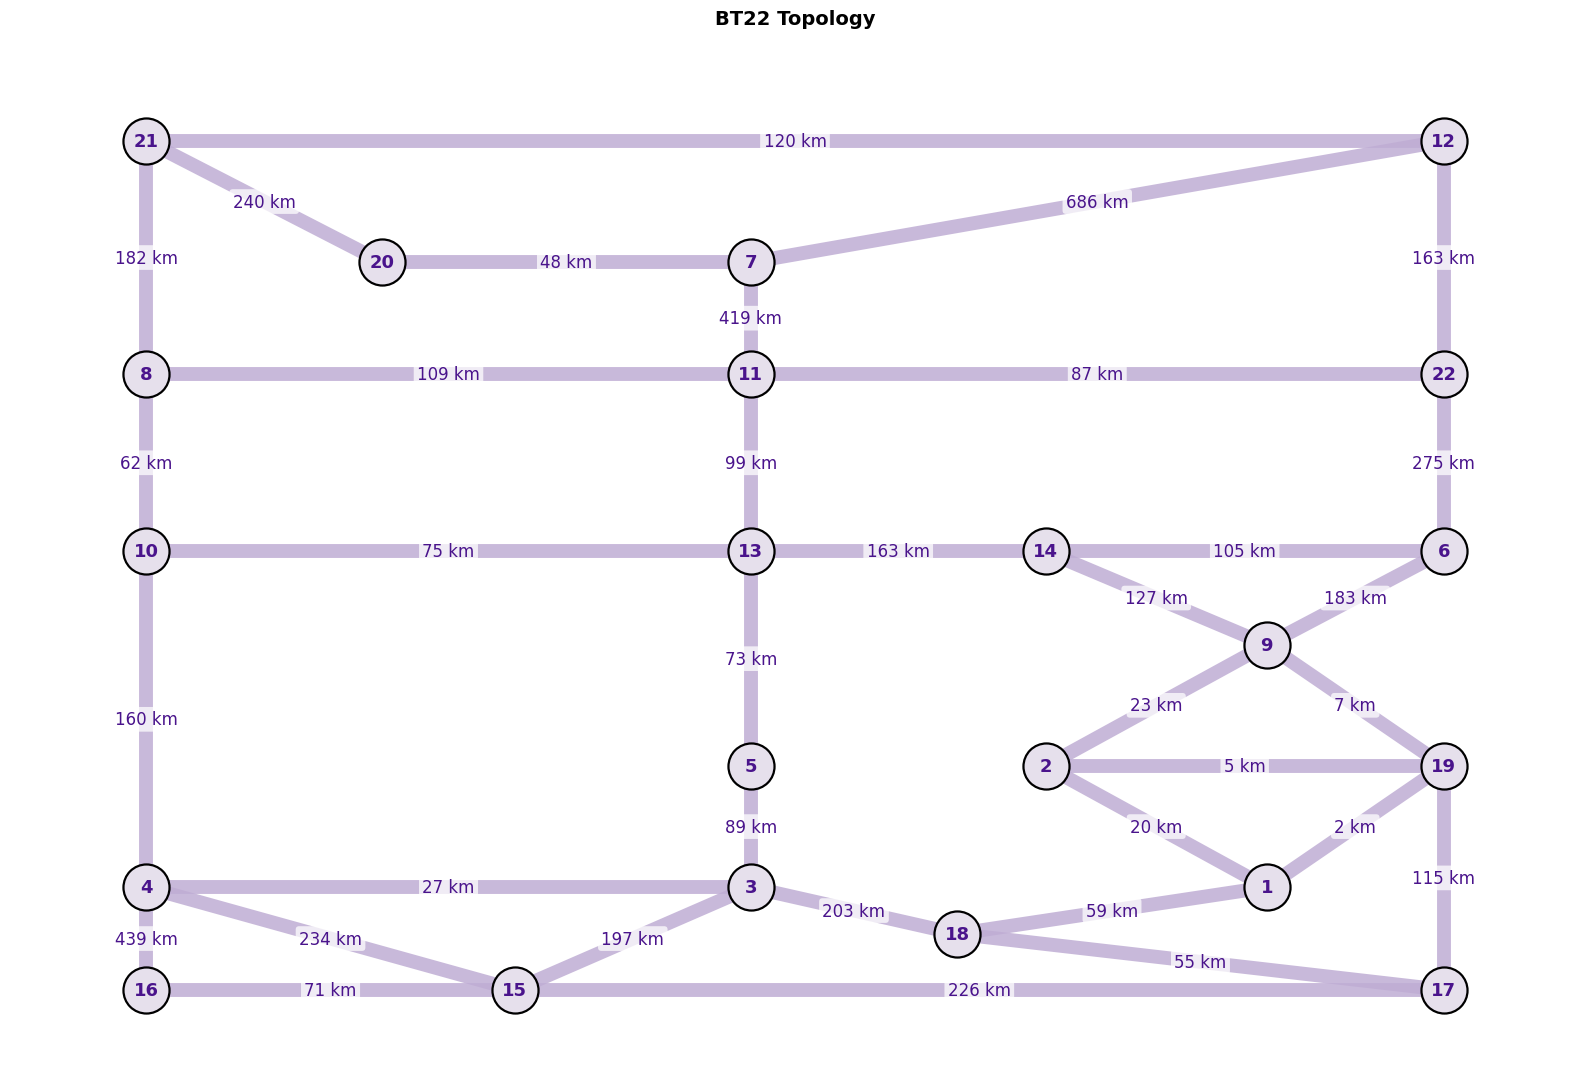

In [41]:
"""
按数据库绘图脚本风格绘制拓扑：设置 topology_name，读取 add_topo/<name>_undirected.json，保存图到 data 目录。
"""

import json
from pathlib import Path

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


def get_node_positions(graph, use_geographic=True, debug=False):
    """获取节点位置（优先使用地理坐标）"""
    pos = {}

    if use_geographic and graph.number_of_nodes() > 0:
        sample_node = next(iter(graph.nodes()))
        if debug:
            print(f"DEBUG sample node: {sample_node}, attrs={graph.nodes[sample_node]}")

        lat_keys = ["Latitude", "latitude", "lat", "Lat"]
        lon_keys = ["Longitude", "longitude", "lon", "Lon", "lng", "Lng"]

        lat_key = None
        lon_key = None
        for node in graph.nodes():
            node_attrs = graph.nodes[node]
            lk = next((k for k in lat_keys if k in node_attrs), None)
            ok = next((k for k in lon_keys if k in node_attrs), None)
            if lk and ok:
                lat_key, lon_key = lk, ok
                break

        if lat_key and lon_key:
            nodes_with_coords = [
                n for n in graph.nodes()
                if lat_key in graph.nodes[n] and lon_key in graph.nodes[n]
            ]

            if len(nodes_with_coords) == graph.number_of_nodes():
                for node in graph.nodes():
                    lat = graph.nodes[node].get(lat_key, 0)
                    lon = graph.nodes[node].get(lon_key, 0)

                    if isinstance(lat, str):
                        try:
                            lat = float(lat)
                        except Exception:
                            lat = 0.0
                    if isinstance(lon, str):
                        try:
                            lon = float(lon)
                        except Exception:
                            lon = 0.0

                    pos[node] = (float(lon), float(lat))

                if debug:
                    print(f"DEBUG use geo keys: {lat_key}, {lon_key}")
                return pos

    if debug:
        print("DEBUG use spring layout")

    try:
        k = 1.1 / max(np.sqrt(max(graph.number_of_nodes(), 1)), 1)
        pos = nx.spring_layout(graph, k=k, iterations=300, seed=42)
    except Exception:
        try:
            pos = nx.kamada_kawai_layout(graph)
        except Exception:
            pos = nx.circular_layout(graph)

    return pos


def plot_topology(graph, title="Network Topology", save_path=None,
                  show_node_labels=True, show_edge_labels=False,
                  show_edge_weights=True, node_size=700,
                  node_color="white", edge_color="dimgray",
                  figsize=(13, 10), use_geographic=True,
                  font_size=11, edge_width=2.0, km_per_weight=80,
                  node_label_color="#4A148C", edge_label_color="#4A148C",
                  debug=False, transparent=False):
    """绘制拓扑图（与数据库版本风格一致）"""
    plt.style.use("default")
    fig, ax = plt.subplots(figsize=figsize)
    if transparent:
        fig.patch.set_facecolor("none")
        ax.set_facecolor("none")

    pos = get_node_positions(graph, use_geographic=use_geographic, debug=debug)

    nx.draw_networkx_edges(
        graph, pos, ax=ax, edge_color=edge_color, width=edge_width, alpha=0.85
    )

    nx.draw_networkx_nodes(
        graph, pos, ax=ax,
        node_size=node_size,
        node_color=node_color,
        alpha=1.0,
        edgecolors="black",
        linewidths=1.6,
    )

    if show_node_labels:
        labels = {n: str(n) for n in graph.nodes()}
        nx.draw_networkx_labels(
            graph, pos, labels=labels, ax=ax,
            font_size=font_size, font_weight="bold", font_color=node_label_color
        )

    if show_edge_labels or show_edge_weights:
        edge_labels = {}
        for u, v, attrs in graph.edges(data=True):
            if show_edge_weights:
                if "length_km" in attrs:
                    distance_km = int(round(float(attrs["length_km"])))
                elif "distance" in attrs:
                    distance_km = int(round(float(attrs["distance"])))
                elif "weight" in attrs:
                    distance_km = int(round(float(attrs["weight"]) * km_per_weight))
                else:
                    distance_km = None

                if distance_km is not None:
                    edge_labels[(u, v)] = f"{distance_km} km"
                elif show_edge_labels:
                    edge_labels[(u, v)] = f"{u}-{v}"
            elif show_edge_labels:
                edge_labels[(u, v)] = f"{u}-{v}"

        if edge_labels:
            nx.draw_networkx_edge_labels(
                graph, pos, edge_labels=edge_labels, ax=ax,
                font_size=font_size - 1,
                font_color=edge_label_color,
                rotate=False,
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    facecolor="white",
                    alpha=0.75,
                    edgecolor="none",
                ),
            )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=20)
    ax.axis("off")
    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            transparent=transparent,
        )
        print(f"Topology plot saved to: {save_path}")

    return fig, ax


def load_graph_from_topo_json(json_path, span_length_km=80):
    """从 *_undirected.json 构建无向图"""
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    graph = nx.Graph()

    for node in data.get("nodes", []):
        node_id = node.get("id")
        if node_id is None:
            continue
        graph.add_node(
            int(node_id),
            name=node.get("name", str(node_id)),
            latitude=float(node.get("latitude", 0.0)),
            longitude=float(node.get("longitude", 0.0)),
            Latitude=float(node.get("latitude", 0.0)),
            Longitude=float(node.get("longitude", 0.0)),
        )

    for link in data.get("links", []):
        u = int(link["source"])
        v = int(link["target"])
        distance_km = float(link.get("distance", 0.0))
        weight = int(np.ceil(distance_km / span_length_km)) if distance_km > 0 else 1
        graph.add_edge(
            u, v,
            distance=distance_km,
            length_km=distance_km,
            weight=weight,
            span_length_km=span_length_km,
        )

    return graph


# ---------------------------------------------------------------------------
# 设置拓扑名（与 add_topo/<topology_name>_undirected.json 对应，不含后缀）
# e.g. cost37, cost266, DTAG, RegularDCI, nsfnet ...BT22
# ---------------------------------------------------------------------------
topology_name = "BT22"

json_filename = f"{topology_name}_undirected.json"
json_candidates = [
    Path("add_topo") / json_filename,
    Path("thesis/throughput_upperbound/simulations/add_topo") / json_filename,
]
json_path = next((p.resolve() for p in json_candidates if p.exists()), None)
if json_path is None:
    raise FileNotFoundError(
        "JSON not found. Tried:\n  " + "\n  ".join(str(p) for p in json_candidates)
    )

out_dir_candidates = [
    Path("thesis/throughput_upperbound/simulations/data"),
    Path("data"),
]
out_dir = next((p for p in out_dir_candidates if p.parent.exists()), out_dir_candidates[-1])
out_dir.mkdir(parents=True, exist_ok=True)
save_path = out_dir / f"{topology_name}_topology.png"

G = load_graph_from_topo_json(json_path, span_length_km=80)

print(f"Loaded topology from: {json_path}")
print(f"Nodes={G.number_of_nodes()}, Edges={G.number_of_edges()}")
print(f"Saving figure to: {save_path.resolve()}")

fig, ax = plot_topology(
    G,
    title=f"{topology_name} Topology",
    save_path=save_path,
    edge_color="#BFADD4",
    node_label_color="#4A148C",
    node_color="#E6E0EC",
    use_geographic=True,
    show_node_labels=True,
    show_edge_weights=True,
    node_size=1100,
    edge_width=10.0,
    figsize=(16, 11),
    font_size=13,
    debug=False,
    km_per_weight=80,
    transparent=True,
)
plt.show()


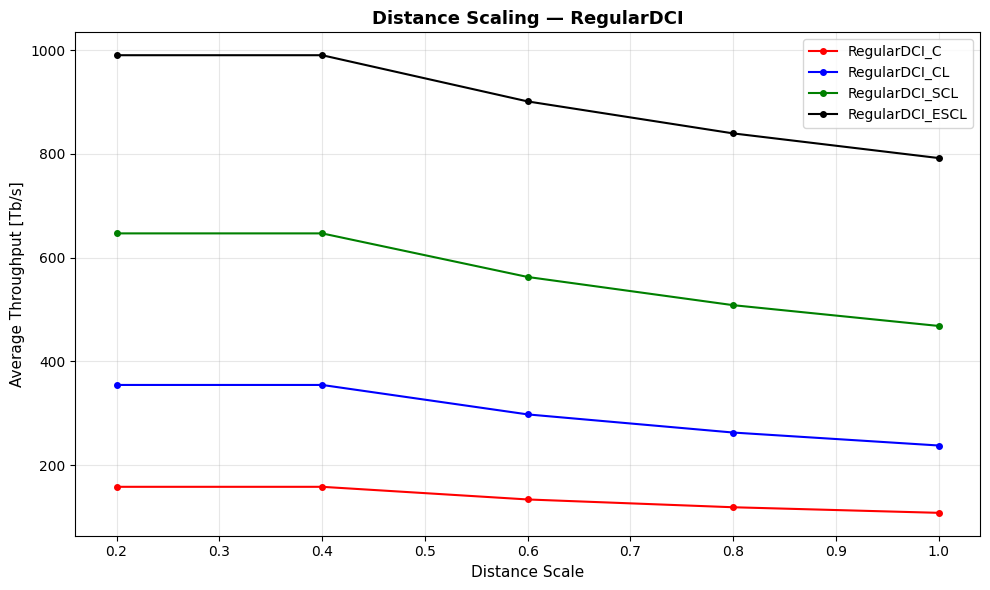

Workbook: /home/uceebd1/pycharm_projects/network_simulations/thesis/throughput_upperbound/simulations/data/scaling_summary.xlsx
Topology: RegularDCI
Band columns plotted: ['C', 'CL', 'SCL', 'ESCL']


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Distance-scaling throughput from scaling_summary.xlsx (one topology)
# Edit `topology_name` (and optionally `route_function_name`) then re-run.
# ------------------------------------------------------------
candidate_paths = [
    Path("data") / "scaling_summary.xlsx",
    Path("thesis/throughput_upperbound/simulations/data") / "scaling_summary.xlsx",
    Path.cwd() / "data" / "scaling_summary.xlsx",
    Path.cwd() / "thesis/throughput_upperbound/simulations/data" / "scaling_summary.xlsx",
]

xlsx_path = next((p.resolve() for p in candidate_paths if p.exists()), None)

topology_name = "RegularDCI"
# e.g. CORONET_CONUS_Topology_nodes JPN25 DTAG germany50 nobel-eu RegularDCI NSFNET cost266

route_function_name = None  # e.g. "kSP-FF", or None for all rows

# Match CSV-style plots; ESCL uses the same color role as SCLO in older CSVs
colors = {
    "C": "red",
    "CL": "blue",
    "SCL": "green",
    "ESCL": "black",
    "SCLO": "black",
}

if xlsx_path is None:
    raise FileNotFoundError(
        "Could not find scaling_summary.xlsx. Tried: "
        + ", ".join(str(p) for p in candidate_paths)
    )

df = pd.read_excel(xlsx_path)
required_cols = {"topology", "scale"}
if not required_cols.issubset(df.columns):
    raise RuntimeError(
        f"Workbook must contain columns {required_cols}; got {list(df.columns)}"
    )

available_topologies = sorted(df["topology"].dropna().astype(str).unique().tolist())
if topology_name not in available_topologies:
    raise RuntimeError(
        f"Topology '{topology_name}' not found. Available: {available_topologies}"
    )

plot_df = df[df["topology"].astype(str) == topology_name].copy()
if route_function_name is not None and "route_function" in plot_df.columns:
    plot_df = plot_df[plot_df["route_function"].astype(str) == route_function_name].copy()

if plot_df.empty:
    raise RuntimeError(
        f"No rows after filter topology={topology_name!r}, route_function={route_function_name!r}"
    )

band_order = ["C", "CL", "SCL", "ESCL", "SCLO"]
band_columns = [b for b in band_order if b in plot_df.columns]
if not band_columns:
    raise RuntimeError(
        f"No band throughput columns found (expected any of {band_order}); got {list(plot_df.columns)}"
    )

plt.figure(figsize=(10, 6))

for band in band_columns:
    agg = (
        plot_df.groupby("scale", as_index=False)[band]
        .mean(numeric_only=True)
        .sort_values("scale")
    )
    agg = agg.dropna(subset=[band])
    if agg.empty:
        print(f"[WARN] No numeric data for band column {band!r}")
        continue

    plt.plot(
        agg["scale"],
        agg[band],
        marker="o",
        linewidth=1.5,
        markersize=4,
        color=colors.get(band, None),
        label=f"{topology_name}_{band}",
    )

title_route = f" ({route_function_name})" if route_function_name else ""
plt.title(
    f"Distance Scaling — {topology_name}{title_route}",
    fontsize=13,
    weight="bold",
)
plt.xlabel("Distance Scale", fontsize=11)
plt.ylabel("Average Throughput [Tb/s]", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"Workbook: {xlsx_path}")
print(f"Topology: {topology_name}")
print(f"Band columns plotted: {band_columns}")

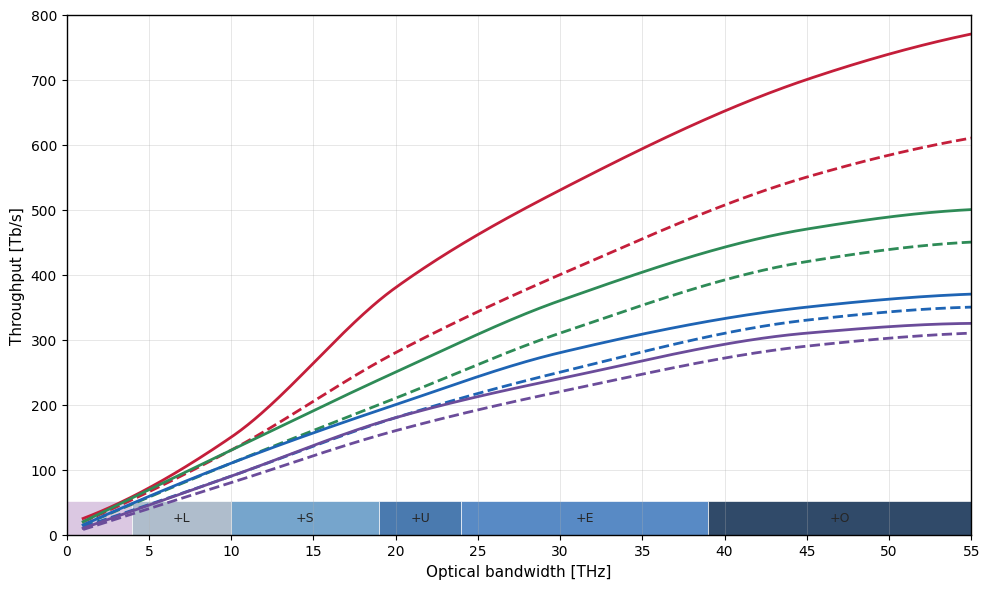

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory

# Synthetic data matching the reference figure (no external files).
x_pts = np.array([1.0, 10.0, 20.0, 30.0, 45.0, 55.0])

series = [
    # (color, linestyle, y values at x_pts)
    ("#C41E3A", "-", [25, 150, 380, 530, 700, 770]),   # red solid
    ("#C41E3A", "--", [20, 130, 280, 400, 550, 610]),  # red dashed
    ("#2E8B57", "-", [20, 130, 250, 360, 470, 500]),   # green solid
    ("#2E8B57", "--", [15, 110, 210, 310, 420, 450]),  # green dashed
    ("#1E64B4", "-", [15, 110, 200, 280, 350, 370]),   # blue solid
    ("#1E64B4", "--", [12, 90, 180, 250, 330, 350]),   # blue dashed
    ("#6B4C9A", "-", [10, 90, 180, 240, 310, 325]),    # purple solid
    ("#6B4C9A", "--", [8, 80, 160, 220, 290, 310]),    # purple dashed
]

try:
    from scipy.interpolate import PchipInterpolator

    def smooth_curve(x_anchor, y_anchor, n=400):
        x_anchor = np.asarray(x_anchor, dtype=float)
        y_anchor = np.asarray(y_anchor, dtype=float)
        order = np.argsort(x_anchor)
        xa, ya = x_anchor[order], y_anchor[order]
        xf = np.linspace(xa[0], xa[-1], n)
        return xf, PchipInterpolator(xa, ya)(xf)
except ImportError:
    def smooth_curve(x_anchor, y_anchor, n=400):
        x_anchor = np.asarray(x_anchor, dtype=float)
        y_anchor = np.asarray(y_anchor, dtype=float)
        order = np.argsort(x_anchor)
        xa, ya = x_anchor[order], y_anchor[order]
        xf = np.linspace(xa[0], xa[-1], n)
        return xf, np.interp(xf, xa, ya)

fig, ax = plt.subplots(figsize=(10, 6))

# Bottom optical-band bar (inside axes, just above x-axis in data space)
trans = blended_transform_factory(ax.transData, ax.transAxes)
bands = [
    (0.0, 4.0, "#D8C4E0", "C"),
    (4.0, 10.0, "#A8B8C8", "+L"),
    (10.0, 19.0, "#6A9EC8", "+S"),
    (19.0, 24.0, "#3A6FA8", "+U"),
    (24.0, 39.0, "#4A80C0", "+E"),
    (39.0, 55.0, "#1E3A5C", "+O"),
]
bar_ymax = 0.065
for xmin, xmax, face, label in bands:
    ax.axvspan(
        xmin,
        xmax,
        ymin=0.0,
        ymax=bar_ymax,
        facecolor=face,
        edgecolor="white",
        linewidth=0.5,
        alpha=0.92,
        transform=trans,
        clip_on=False,
        zorder=0,
    )
    ax.text(
        0.5 * (xmin + xmax),
        bar_ymax * 0.5,
        label,
        ha="center",
        va="center",
        fontsize=9,
        color="0.15",
        transform=trans,
        zorder=1,
    )

for color, ls, y_vals in series:
    xf, yf = smooth_curve(x_pts, y_vals)
    ax.plot(xf, yf, color=color, linestyle=ls, linewidth=2.0, zorder=2)

ax.set_xlim(0, 55)
ax.set_ylim(0, 800)
ax.set_xlabel("Optical bandwidth [THz]", fontsize=11)
ax.set_ylabel("Throughput [Tb/s]", fontsize=11)
ax.set_xticks(np.arange(0, 56, 5))
ax.set_yticks(np.arange(0, 801, 100))
ax.grid(True, alpha=0.35, linestyle="-", linewidth=0.6)
ax.set_axisbelow(True)
ax.set_facecolor("white")
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color("black")

plt.tight_layout()
plt.show()

Found 21 OESCL link files in data/snr


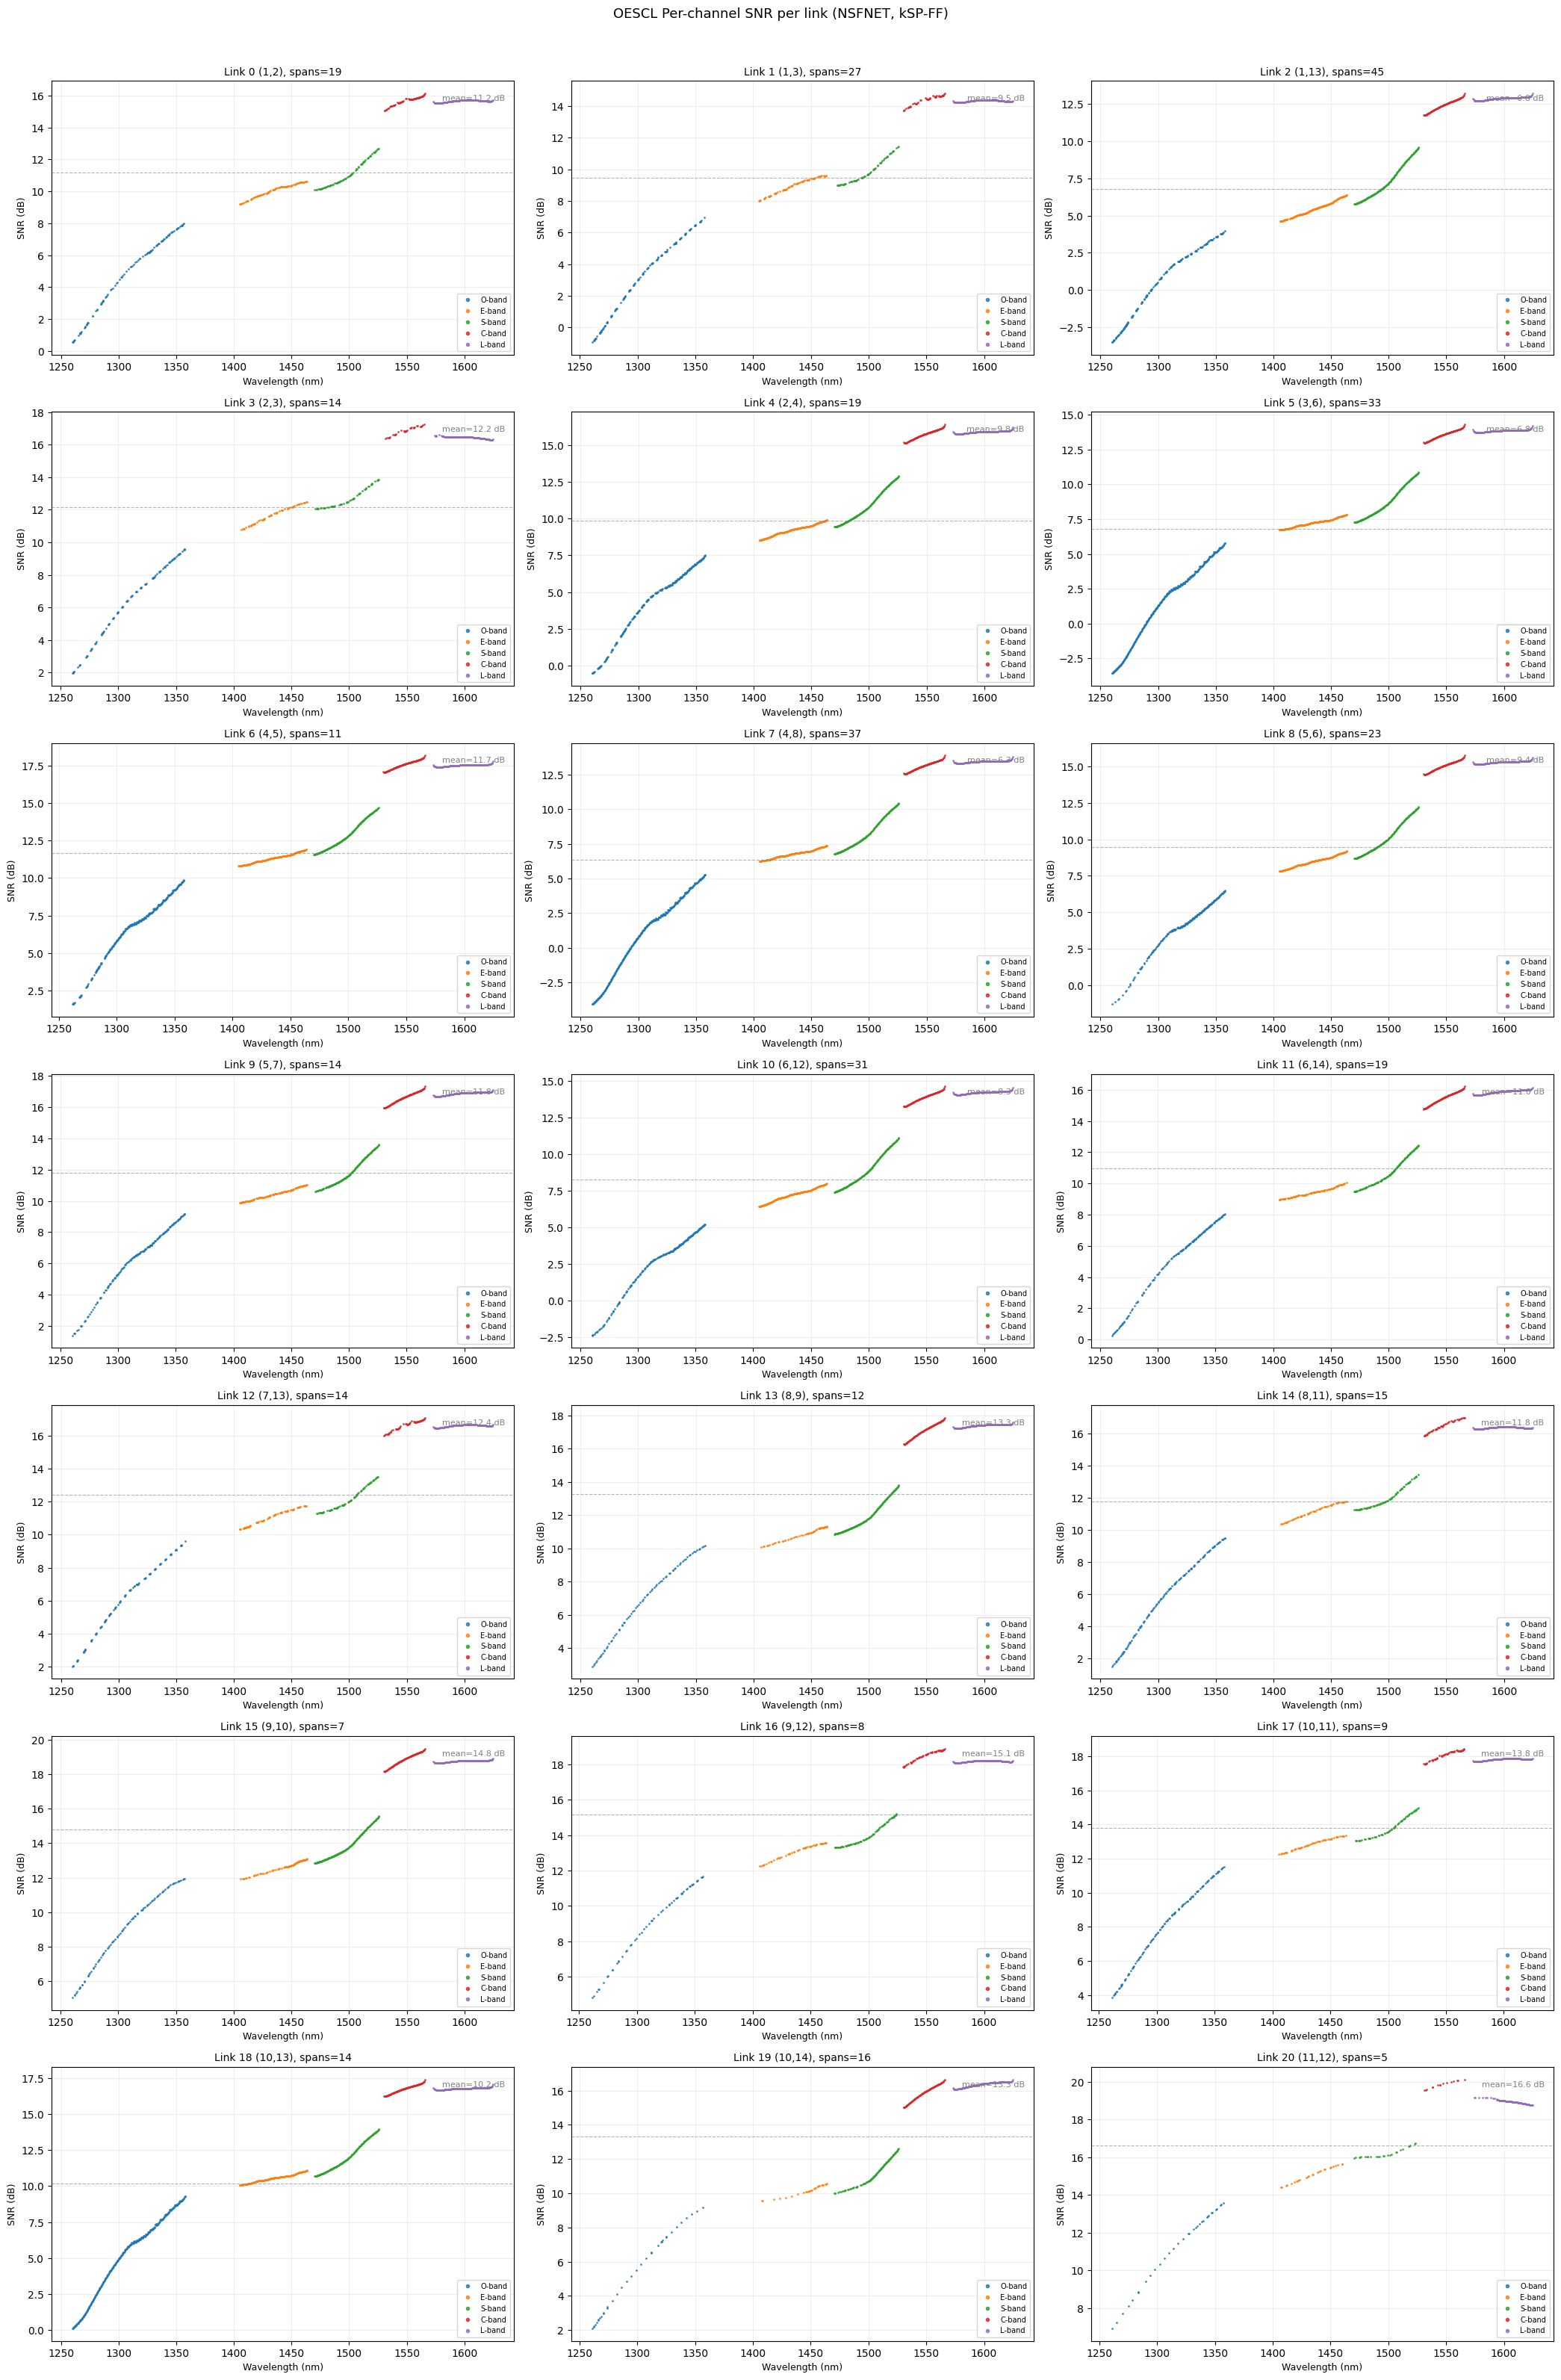

Saved figure to data/snr/5fbd059d6648f5626a4b9a4b_OESCL_kSP-FF_all_links_snr.png


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

snr_dir = Path("data/snr")
prefix = "5fbd059d6648f5626a4b9a4b_OESCL_kSP-FF"
files = sorted(snr_dir.glob(f"{prefix}_link*.npz"),
               key=lambda p: int(p.stem.split("link")[1].split("_")[0]))
print(f"Found {len(files)} OESCL link files in {snr_dir}")

band_colors = {
    "O": "#1f77b4", "E": "#ff7f0e", "S": "#2ca02c",
    "C": "#d62728", "L": "#9467bd",
}
band_bounds_nm = {
    "O": (1260, 1358), "E": (1405, 1464), "S": (1470, 1526),
    "C": (1530, 1566), "L": (1573, 1625),
}

n_files = len(files)
n_cols = min(3, n_files)
n_rows = (n_files + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4.5 * n_rows),
                          squeeze=False)

for idx, fpath in enumerate(files):
    ax = axes[idx // n_cols, idx % n_cols]
    d = np.load(fpath)
    wl_nm = d["wavelength_m"] * 1e9
    snr = d["snr_dB"]
    occ = d["occupancy"].astype(bool)
    edge = d["edge"]
    spans = int(d["spans"])

    for band, (lo, hi) in band_bounds_nm.items():
        mask = (wl_nm >= lo) & (wl_nm <= hi) & occ & np.isfinite(snr)
        if np.any(mask):
            ax.plot(wl_nm[mask], snr[mask], ".", markersize=2,
                    color=band_colors[band], label=f"{band}-band", alpha=0.8)

    valid = occ & np.isfinite(snr)
    if np.any(valid):
        mean_val = np.nanmean(snr[valid])
        ax.axhline(mean_val, color="grey", ls="--", lw=0.8, alpha=0.6)
        ax.text(0.98, 0.95, f"mean={mean_val:.1f} dB",
                transform=ax.transAxes, ha="right", va="top", fontsize=8,
                color="grey")

    ax.set_title(f"Link {idx} ({edge[0]},{edge[1]}), spans={spans}", fontsize=10)
    ax.set_xlabel("Wavelength (nm)", fontsize=9)
    ax.set_ylabel("SNR (dB)", fontsize=9)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.legend(fontsize=7, loc="lower right", markerscale=3)

for idx in range(n_files, n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

fig.suptitle("OESCL Per-channel SNR per link (NSFNET, kSP-FF)", fontsize=13, y=1.01)
plt.tight_layout()
out_path = snr_dir / f"{prefix}_all_links_snr.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved figure to {out_path}")

In [2]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

snr_dir = Path("data/snr")
prefix = "5fbd059d6648f5626a4b9a4b_OESCL_kSP-FF"

# --- 1. Export per-link fit params (a, a_bar, Cr) to Excel ---
link_files = sorted(snr_dir.glob(f"{prefix}_link*.npz"),
                    key=lambda p: int(p.stem.split("link")[1].split("_")[0]))

rows = []
for fpath in link_files:
    d = np.load(fpath)
    wl_nm = d["wavelength_m"] * 1e9
    freq_thz = d["frequency_hz"] * 1e-12
    a = d["a"]
    a_bar = d["a_bar"]
    Cr = d["Cr"]
    edge = d["edge"]
    spans = int(d["spans"])
    link_idx = int(fpath.stem.split("link")[1].split("_")[0])

    snr_dB = d["snr_dB"]
    nsr_lin = d["nsr_linear"]
    occ = d["occupancy"]

    for ch in range(len(wl_nm)):
        rows.append({
            "link": link_idx,
            "edge_u": int(edge[0]),
            "edge_v": int(edge[1]),
            "spans": spans,
            "channel": ch,
            "wavelength_nm": float(wl_nm[ch]),
            "frequency_THz": float(freq_thz[ch]),
            "occupancy": int(occ[ch]),
            "snr_dB": float(snr_dB[ch]),
            "nsr_linear": float(nsr_lin[ch]),
            "a": float(a[ch]),
            "a_bar": float(a_bar[ch]),
            "Cr": float(Cr[ch]),
        })

df = pd.DataFrame(rows)
xlsx_path = snr_dir / f"{prefix}_fit_params.xlsx"
df.to_excel(xlsx_path, index=False, sheet_name="fit_params")
print(f"Saved {len(link_files)} links × {len(df)//len(link_files)} channels to {xlsx_path}")
print(df.head(10))

# --- 2. Export occupancy to JSON ---
occ_path = snr_dir / f"{prefix}_occupancy.npz"
occ_data = np.load(occ_path)

occ_json = {
    "edges": occ_data["edges"].tolist(),
    "spans": occ_data["spans"].tolist(),
    "wavelength_nm": (occ_data["wavelength_m"] * 1e9).tolist(),
    "frequency_THz": (occ_data["frequency_hz"] * 1e-12).tolist(),
    "occupancy_matrix": occ_data["occupancy_matrix"].tolist(),
}

json_path = snr_dir / f"{prefix}_occupancy.json"
with open(json_path, "w") as f:
    json.dump(occ_json, f, indent=2)
print(f"\nSaved occupancy matrix ({occ_data['occupancy_matrix'].shape}) to {json_path}")

Saved 21 links × 878 channels to data/snr/5fbd059d6648f5626a4b9a4b_OESCL_kSP-FF_fit_params.xlsx
   link  edge_u  edge_v  spans  channel  wavelength_nm  frequency_THz  \
0     0       1       2     19        0    1624.797119     184.510681   
1     0       1       2     19        1    1624.356934     184.560699   
2     0       1       2     19        2    1623.917114     184.610672   
3     0       1       2     19        3    1623.477295     184.660690   
4     0       1       2     19        4    1623.037842     184.710693   
5     0       1       2     19        5    1622.598633     184.760681   
6     0       1       2     19        6    1622.159790     184.810684   
7     0       1       2     19        7    1621.720947     184.860687   
8     0       1       2     19        8    1621.282471     184.910690   
9     0       1       2     19        9    1620.844238     184.960663   

   occupancy     snr_dB  nsr_linear         a     a_bar            Cr  
0          1  15.967444    0

IndentationError: expected an indented block after 'for' statement on line 43 (3994577931.py, line 45)

Link 5 (3,6) spans=33 occupied channels = 878


E0416 20:18:24.932699 1546251 xtile_compiler.cc:399] Fusion: gemm_fusion_dot = f32[2,878,878]{2,1,0} fusion(mul.48, constant.83), kind=kCustom, calls=gemm_fusion_dot_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","128","64"]}],"num_ctas":1,"num_stages":5,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0416 20:18:24.932848 1546251 xtile_compiler.cc:401] Computation: gemm_fusion_dot_computation.clone {
  parameter_0 = f32[878,878]{1,0} parameter(0)
  constant = f32[] constant(0)
  pad = f32[878,880]{1,0} pad(parameter_0, constant), padding=0_0x0_2
  bitcast = f32[878,2,440]{2,1,0} bitcast(pad)
  parameter_1 = f32[878,878]{1,0} parameter(1)
  constant_1 = f32[] constant(0)
  pad.1 = f32[878,880]{1,0} pad(p

solve_isrs_evolution took 10.2s (power_evo shape=(80, 878))


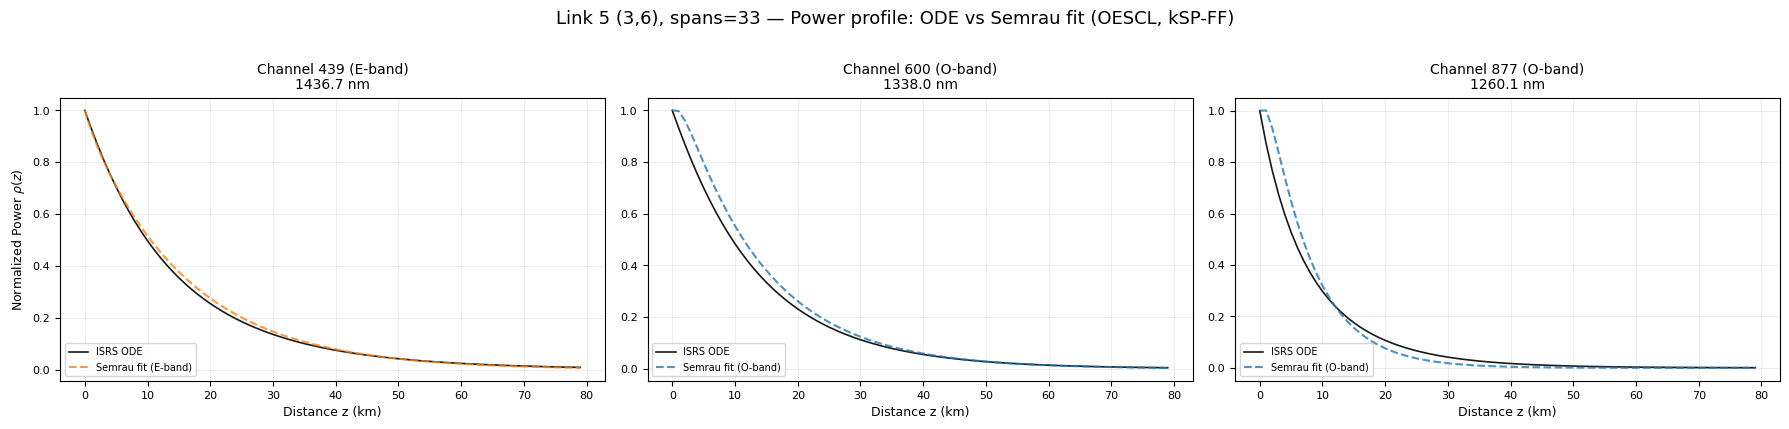

Saved figure to data/snr/5fbd059d6648f5626a4b9a4b_OESCL_kSP-FF_link5_profile_compare.png


In [5]:
"""
Power-profile comparison for a SINGLE link
===========================================
Re-run solve_isrs_evolution for one link, then overlay the Semrau fitted
profile (from saved a, a_bar, Cr) for user-chosen channels.

>>> EDIT THESE TWO VARIABLES <<<
"""
# ── User inputs ──────────────────────────────────────────────────────────
LINK_IDX = 5  # which link (0 .. 20)
CHANNELS = [439, 600, 877]  # channel indices to plot (active-grid)
# ─────────────────────────────────────────────────────────────────────────

import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c

_HERE = Path(".").resolve()
_EXT = _HERE.parents[2] / "external"
_ONG = _EXT / "ong-python-toolbox" / "src"
if str(_EXT) not in sys.path:
    sys.path.insert(0, str(_EXT))
if str(_ONG) not in sys.path:
    sys.path.insert(0, str(_ONG))

from jax import numpy as jnp
import jax
from ong.models import raman_solver, FibreSpanSetupAdvanced, egn
from ong.models.raman_fitting import rho_semi_daniel_solution
from ong.measurements import load_corning_smf_28_raman
from ong.utils import struct
import data as fibre_data

# ---------- constants (same as compute_throughput_cfm.py) ----------
CH_SPACING_HZ = 50e9
CH_BW_HZ = 48e9
N_CH_TOTAL = 1111
REF_LAMBDA_M = 1419.4e-9
SPAN_KM = 80
LAUNCH_dBm = -2.0

_BAND_BOUNDS = {
    "O": (1260e-9, 1358e-9),
    "E": (1405e-9, 1464e-9),
    "S": (1470e-9, 1526e-9),
    "C": (1530e-9, 1566e-9),
    "L": (1573e-9, 1625e-9),
}
BANDS = {
    "O": {"noise_figure": 5, "p_launch": 23},
    "E": {"noise_figure": 6, "p_launch": 15.57},
    "S": {"noise_figure": 7, "p_launch": 14.03},
    "C": {"noise_figure": 5, "p_launch": 20.69},
    "L": {"noise_figure": 5.5, "p_launch": 21.9},
}
ACTIVE_BANDS = ["O", "E", "S", "C", "L"]
idBm = lambda x: 10 ** (x / 10) * 1e-3

# ---------- channel grid ----------
chs_idx = jnp.arange(N_CH_TOTAL) - (N_CH_TOTAL - 1) / 2
ch_lambda = c / (chs_idx * CH_SPACING_HZ + c / REF_LAMBDA_M)
band_masks = {}
for b, (lo, hi) in _BAND_BOUNDS.items():
    band_masks[b] = (ch_lambda >= lo) & (ch_lambda <= hi)
channel_idx = jnp.zeros(N_CH_TOTAL, dtype=bool)
for b in ACTIVE_BANDS:
    channel_idx = channel_idx | band_masks[b]
channel_idx_np = np.asarray(channel_idx)
ch_lambda_np = np.asarray(ch_lambda)

# ---------- per-channel launch power ----------
P_ch = -jnp.inf * jnp.ones(N_CH_TOTAL)
for b in ACTIVE_BANDS:
    P_ch = P_ch.at[band_masks[b]].set(LAUNCH_dBm)
P_W = idBm(np.asarray(P_ch))

# ---------- fibre span ----------
lambda_active = ch_lambda_np[channel_idx_np]
fibre_span = FibreSpanSetupAdvanced(
    length=f"{SPAN_KM}km",
    dispersion_order=2,
    dispersion_ref_lambda=REF_LAMBDA_M,
    dispersion_fit_points=jnp.array(
        [float(min(lambda_active)), REF_LAMBDA_M, float(max(lambda_active))]
    ),
    attenuation_profile=fibre_data.fit_attenuation("min"),
    raman_profile=load_corning_smf_28_raman(),
    dispersion_profile=fibre_data.get_dispersion("min"),
    effective_area_profile=(
        jnp.array([1310e-9, 1550e-9]),
        jnp.array([66.476e-12, 86.59e-12]),
    ),
    nonlinear_coeff_profile=(jnp.array([1310e-9]), jnp.array([2e-3])),
)

# ---------- load saved data for the chosen link ----------
snr_dir = Path("data/snr")
prefix = "5fbd059d6648f5626a4b9a4b_OESCL_kSP-FF"

occ_data = np.load(snr_dir / f"{prefix}_occupancy.npz")
edges_all = occ_data["edges"]
spans_all = occ_data["spans"]
occ_matrix = occ_data["occupancy_matrix"]

u, v = edges_all[LINK_IDX]
n_spans = int(spans_all[LINK_IDX])
occ_vec = occ_matrix[LINK_IDX]

link_files = sorted(snr_dir.glob(f"{prefix}_link{LINK_IDX}_*.npz"))
if not link_files:
    raise FileNotFoundError(f"No .npz for link {LINK_IDX}")
ld = np.load(link_files[0])
a_saved = ld["a"]
a_bar_saved = ld["a_bar"]
Cr_saved = ld["Cr"]

print(
    f"Link {LINK_IDX} ({u},{v}) spans={n_spans} "
    f"occupied channels = {int(occ_vec.sum())}"
)

# ---------- re-run ISRS ODE for this link ----------
active_idx = np.flatnonzero(channel_idx_np)

# ch_centre_ij = relative frequency offsets (same formula as GNSetup.ch_centre_ij)
all_ch_offsets = (jnp.arange(N_CH_TOTAL) - (N_CH_TOTAL - 1) / 2) * CH_SPACING_HZ
ch_centre_active = np.asarray(all_ch_offsets[channel_idx_np])

atten_active = np.asarray(
    fibre_span.attenuation_at(ch_lambda_np[channel_idx_np])
)
Aeff_active = jnp.array(fibre_span.A_eff_at(ch_lambda_np[channel_idx_np]))

P_active = P_W[channel_idx_np] * occ_vec  # zero out unoccupied

L = float(fibre_span.length)
z = jnp.arange(0, L, 1000)

t0 = time.perf_counter()
_, power_evo = raman_solver.solve_isrs_evolution(
    ch_centre_i=jnp.array(ch_centre_active),
    A_eff=Aeff_active,
    raman_profile=fibre_span.raman_profile,
    length=L,
    attenuation_i=jnp.array(atten_active),
    ch_power_W_i=jnp.array(P_active),
    ref_lambda=REF_LAMBDA_M,
    zspan=z,
)
dt = time.perf_counter() - t0
print(f"solve_isrs_evolution took {dt:.1f}s (power_evo shape={power_evo.shape})")

# normalise
power_evo_np = np.asarray(power_evo)
rho_true = power_evo_np / power_evo_np[0:1, :]  # (Nz, Nch)

# ---------- reconstruct Semrau fitted profile ----------
neper = np.log(10) / 10
P_total = float(np.sum(P_active))
z_np = np.asarray(z)

# a, a_bar saved in dB/m → convert to Np/m for rho_semi_daniel_solution
a_np = a_saved * neper
a_bar_np = a_bar_saved * neper
Cr_np = Cr_saved


def fitted_rho(ch_i):
    params = jnp.array([a_np[ch_i], a_bar_np[ch_i], Cr_np[ch_i]])
    f_i = ch_centre_active[ch_i]
    return np.asarray(rho_semi_daniel_solution(params, P_total, f_i, z))


# ---------- plot (style aligned with per-link SNR summary cell) ----------
band_colors = {
    "O": "#1f77b4",
    "E": "#ff7f0e",
    "S": "#2ca02c",
    "C": "#d62728",
    "L": "#9467bd",
}
band_bounds_nm = {
    "O": (1260, 1358),
    "E": (1405, 1464),
    "S": (1470, 1526),
    "C": (1530, 1566),
    "L": (1573, 1625),
}

n_plot = len(CHANNELS)
fig, axes = plt.subplots(1, n_plot, figsize=(6 * n_plot, 4.2), squeeze=False)
axes = axes.flatten()

z_km = z_np / 1e3

for ax, ch in zip(axes, CHANNELS):
    if not (0 <= ch < rho_true.shape[1]):
        ax.set_title(f"ch {ch}: out of range", fontsize=10)
        continue

    wl_nm = lambda_active[ch] * 1e9

    current_band = "?"
    current_color = "black"
    for band, (lo, hi) in band_bounds_nm.items():
        if lo <= wl_nm <= hi:
            current_band = band
            current_color = band_colors[band]
            break

    ax.plot(z_km, rho_true[:, ch], "k-", lw=1.2, label="ISRS ODE", alpha=0.9)

    if occ_vec[ch]:
        rho_fit = fitted_rho(ch)
        ax.plot(
            z_km,
            rho_fit,
            "--",
            color=current_color,
            lw=1.5,
            label=f"Semrau fit ({current_band}-band)",
            alpha=0.8,
        )
    else:
        ax.text(
            0.5,
            0.5,
            "Unoccupied",
            transform=ax.transAxes,
            ha="center",
            va="center",
            color="grey",
            fontsize=11,
            alpha=0.6,
        )

    ax.set_title(
        f"Channel {ch} ({current_band}-band)\n{wl_nm:.1f} nm",
        fontsize=10,
    )
    ax.set_xlabel("Distance z (km)", fontsize=9)
    if ax is axes[0]:
        ax.set_ylabel(r"Normalized Power $\rho(z)$", fontsize=9)

    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.legend(fontsize=7, loc="lower left", frameon=True)
    ax.tick_params(axis="both", which="major", labelsize=8)

fig.suptitle(
    f"Link {LINK_IDX} ({u},{v}), spans={n_spans} — "
    f"Power profile: ODE vs Semrau fit (OESCL, kSP-FF)",
    fontsize=13,
    y=1.01,
)
plt.tight_layout()

out_path = snr_dir / f"{prefix}_link{LINK_IDX}_profile_compare.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved figure to {out_path}")




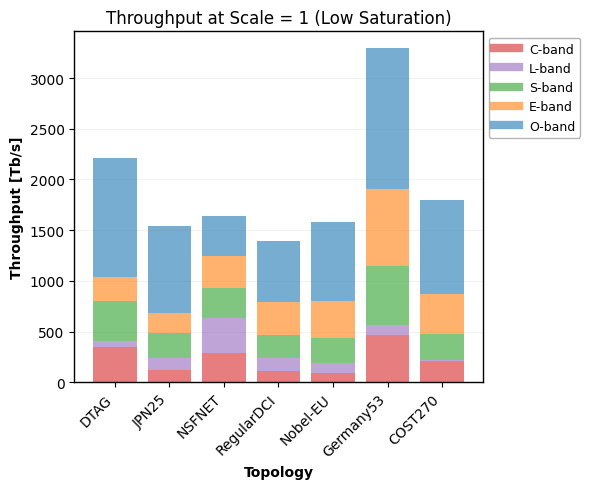

Saved narrowed, low-saturation figure to: data/figures/throughput_scale1_stacked_bar.png


In [22]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# =========================================================
# 1. Input path (保持原逻辑)
# =========================================================
candidate_excel_paths = [
    Path("thesis/throughput_upperbound/simulations/data/scaling_summary.xlsx"),
    Path("./thesis/throughput_upperbound/simulations/data/scaling_summary.xlsx"),
    Path("data") / "scaling_summary.xlsx",
    Path("thesis/throughput_upperbound/simulations/data") / "scaling_summary.xlsx",
    Path.cwd() / "data" / "scaling_summary.xlsx",
    Path.cwd() / "thesis" / "throughput_upperbound" / "simulations" / "data" / "scaling_summary.xlsx",
    Path("/mnt/data/scaling_summary.xlsx"),
]

excel_path = None
for pth in candidate_excel_paths:
    if pth.exists():
        excel_path = pth
        break

if excel_path is None:
    raise FileNotFoundError("Could not find scaling_summary.xlsx.")

# =========================================================
# 2. Output directory
# =========================================================
output_dir = excel_path.parent / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "throughput_scale1_stacked_bar.png"

# =========================================================
# 3. Colors
# =========================================================
band_colors = {
    "O": "#1f77b4",
    "E": "#ff7f0e",
    "S": "#2ca02c",
    "C": "#d62728",
    "L": "#9467bd",
}

def _scalar_float(val):
    if val is None: return float("nan")
    if isinstance(val, (int, float, np.integer, np.floating)): return float(val)
    m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", str(val))
    return float(m.group(0)) if m else float("nan")

# =========================================================
# 4. Read Excel & Filter
# =========================================================
df = pd.read_excel(excel_path)
required_cols = ["topology", "scale", "C", "CL", "SCL", "ESCL", "OESCL"]
df = df[required_cols].copy()

for col in ["scale", "C", "CL", "SCL", "ESCL", "OESCL"]:
    df[col] = df[col].map(_scalar_float)

df = df[np.isclose(df["scale"], 1.0, rtol=0.0, atol=1e-9)]
df = df.dropna(subset=["topology"]).reset_index(drop=True)

# =========================================================
# 5. Build stacked increments
# =========================================================
df["L_increment"] = (df["CL"] - df["C"]).clip(lower=0)
df["S_increment"] = (df["SCL"] - df["CL"]).clip(lower=0)
df["E_increment"] = (df["ESCL"] - df["SCL"]).clip(lower=0)
df["O_increment"] = (df["OESCL"] - df["ESCL"]).clip(lower=0)

# =========================================================
# 6. Plotting (关键修改区)
# =========================================================
_style = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "grid.color": "#bfbfbf",
    "grid.alpha": 0.35,
}

# 调窄图表宽度逻辑
x = np.arange(len(df))
width = 0.8  # 增加柱子宽度，看起来更扎实
fig_w = float(np.clip(0.35 * len(df) + 2.5, 6.0, 12.0)) # 窄版宽度
fig_h = 5.0
bar_alpha = 0.6  # 设置透明度以降低饱和度

with plt.rc_context(_style):
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor="white")
    ax.set_axisbelow(True)

    # 绘制各波段并应用透明度
    ax.bar(x, df["C"], width=width, color=band_colors["C"], edgecolor="none", alpha=bar_alpha)
    ax.bar(x, df["L_increment"], width=width, bottom=df["C"], color=band_colors["L"], edgecolor="none", alpha=bar_alpha)
    ax.bar(x, df["S_increment"], width=width, bottom=df["CL"], color=band_colors["S"], edgecolor="none", alpha=bar_alpha)
    ax.bar(x, df["E_increment"], width=width, bottom=df["SCL"], color=band_colors["E"], edgecolor="none", alpha=bar_alpha)
    ax.bar(x, df["O_increment"], width=width, bottom=df["ESCL"], color=band_colors["O"], edgecolor="none", alpha=bar_alpha)

    ax.set_xticks(x)
    ax.set_xticklabels(df["topology"], rotation=45, ha="right")
    ax.set_xlabel("Topology", fontweight='bold')
    ax.set_ylabel("Throughput [Tb/s]", fontweight='bold')
    ax.set_title("Throughput at Scale = 1 (Low Saturation)")

    ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.3)

    # 图例处理：确保图例颜色也带透明度
    handles = [
        Line2D([0], [0], color=band_colors[k], lw=6, alpha=bar_alpha, label=f"{k}-band")
        for k in ("C", "L", "S", "E", "O")
    ]
    ax.legend(
        handles=handles, loc="upper left", ncol=1, frameon=True,
        edgecolor="#a0a0a0", fontsize=9, bbox_to_anchor=(1, 1) # 图例移到右侧外面防止遮挡
    )

    fig.tight_layout()

fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved narrowed, low-saturation figure to: {output_path}")

In [44]:
"""Insert BT22 from add_topo/BT22_undirected.json into MongoDB.

Mongo layout (same defaults as ``compute_throughput_cfm.py`` / ``ff_k_sp.py``):
  database ``Topology_Data``, collection ``real``, document field ``name`` = ``"BT22"``.
  (Here ``real`` is the *collection*; ``BT22`` is the topology *name*, not a collection.)

What matters for RWA + CFM throughput:
  - Node ids and adjacency (links).
  - Edge ``weight`` = span count. JSON gives ``distance`` in km; we set
    ``weight = ceil(distance / SPAN_LENGTH_KM)`` like other import scripts.
  - ``length_km`` / ``distance`` kept on edges for reference.

Geography (latitude/longitude on nodes) is saved with ``node_data=True`` for plotting;
``compute_throughput_cfm`` and ``ff_k_sp`` do **not** use lat/lon in the throughput path.
"""
import json
from pathlib import Path

import networkx as nx
import numpy as np
import NetworkToolkit as nt

DB_NAME = "Topology_Data"
COLLECTION_NAME = "real"
TOPOLOGY_NAME = "BT22"
SPAN_LENGTH_KM = 80.0

_json_candidates = [
    Path("add_topo") / "BT22_undirected.json",
    Path("thesis/throughput_upperbound/simulations/add_topo") / "BT22_undirected.json",
]
json_path = next((p.resolve() for p in _json_candidates if p.exists()), None)
if json_path is None:
    raise FileNotFoundError(
        "BT22_undirected.json not found. Tried:\n  " + "\n  ".join(str(p) for p in _json_candidates)
    )

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

G = nx.Graph()
for node in data.get("nodes", []):
    nid = int(node["id"])
    lat = float(node.get("latitude", 0.0))
    lon = float(node.get("longitude", 0.0))
    G.add_node(
        nid,
        name=str(node.get("name", str(nid))),
        type=str(node.get("type", "")),
        latitude=lat,
        longitude=lon,
        Latitude=lat,
        Longitude=lon,
    )

for link in data.get("links", []):
    u, v = int(link["source"]), int(link["target"])
    dist_km = float(link.get("distance", 0.0))
    weight = int(np.ceil(dist_km / SPAN_LENGTH_KM)) if dist_km > 0 else 1
    G.add_edge(
        u,
        v,
        distance=dist_km,
        length_km=dist_km,
        weight=weight,
        span_length_km=SPAN_LENGTH_KM,
    )

print(f"Loaded: {json_path}")
print(f"  nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")

existing = list(
    nt.Database.read_data(
        DB_NAME, COLLECTION_NAME, find_dic={"name": TOPOLOGY_NAME}, max_count=20
    )
)
if existing:
    print(
        f"WARNING: {len(existing)} doc(s) already named {TOPOLOGY_NAME!r}. "
        "insert_graph adds another document; remove duplicates in Mongo if you need a single doc."
    )

extra = {
    "name": TOPOLOGY_NAME,
    "nodes": G.number_of_nodes(),
    "edges": G.number_of_edges(),
    "description": "BT22 undirected topology from BT22_undirected.json",
    "source_file": str(json_path),
}

nt.Database.insert_graph(
    G,
    DB_NAME,
    COLLECTION_NAME,
    node_data=True,
    **extra,
)

gl = nt.Database.read_topology_dataset_list(
    DB_NAME,
    COLLECTION_NAME,
    find_dic={"name": TOPOLOGY_NAME},
    node_data=True,
    max_count=1,
)
if gl:
    g2, _id = gl[0]
    e0 = next(iter(g2.edges()))
    n0 = sorted(g2.nodes())[0]
    print(f"Read-back OK _id={_id}, sample edge {e0}: {dict(g2.edges[e0])}")
    print(f"  sample node {n0}: {dict(g2.nodes[n0])}")
else:
    print("Read-back failed (check Mongo credentials / tunnel).")


Loaded: /home/uceebd1/pycharm_projects/network_simulations/thesis/throughput_upperbound/simulations/add_topo/BT22_undirected.json
  nodes=22, edges=35


reading data in real: 1it [00:00, 17.27it/s]

Read-back OK _id=69e242d0a05a760ab5de14c3, sample edge (1, 2): {'distance': 20.0, 'length_km': 20.0, 'weight': 1, 'span_length_km': 80.0}
  sample node 1: {}


In [46]:
# MongoDB RWA: exact key = f"{ROUTE_FUNCTION_HINT} {BAND.upper()} RWA"
import pprint
import NetworkToolkit as nt

TOPOLOGY_NAME = "cost266"
BAND = "OESCL"
ROUTE_FUNCTION_HINT = "kSP-FF"
DB = "Topology_Data"
COLLECTION = "real"
DOC_INDEX = 0

rwa_key = f"{ROUTE_FUNCTION_HINT.strip()} {BAND.strip().upper()} RWA"

docs = list(nt.Database.read_data(DB, COLLECTION, find_dic={"name": TOPOLOGY_NAME}, max_count=50))
if not docs:
    raise RuntimeError(f"No documents with name={TOPOLOGY_NAME!r} in {DB}.{COLLECTION}")
if DOC_INDEX < 0 or DOC_INDEX >= len(docs):
    raise IndexError(f"DOC_INDEX={DOC_INDEX} out of range (found {len(docs)})")

doc = docs[DOC_INDEX]
if rwa_key not in doc:
    suf = f" {BAND.strip().upper()} RWA"
    same = sorted(k for k in doc if isinstance(k, str) and k.endswith(suf))
    raise KeyError(f"No key {rwa_key!r}. Same-band keys: {same}")

rwa = nt.Tools.read_database_dict(doc[rwa_key])
pprint.pprint(rwa, width=200)


{0: [[1, 15, 5, 24, 34, 36, 2],
     [1, 19, 18, 21, 3],
     [1, 14, 6],
     [1, 8, 27, 7],
     [2, 26, 29, 22, 3],
     [2, 31, 4],
     [3, 30],
     [4, 9, 28, 5],
     [4, 36, 29, 23],
     [5, 10],
     [5, 35, 16],
     [6, 19],
     [7, 22, 20],
     [7, 21],
     [8, 12],
     [9, 17],
     [10, 25, 16],
     [10, 32],
     [11, 14],
     [11, 19],
     [12, 13],
     [13, 15],
     [13, 33, 27, 20],
     [13, 24, 23],
     [16, 32],
     [17, 35],
     [18, 30],
     [19, 27],
     [20, 37, 23],
     [28, 34],
     [33, 37]],
 1: [[1, 15, 5, 28, 9, 4],
     [1, 8],
     [1, 14, 11],
     [1, 19, 18],
     [2, 36, 34, 24, 5],
     [2, 26, 29, 22, 7, 27, 19, 6],
     [2, 31],
     [3, 21, 7],
     [3, 22, 20],
     [4, 36, 29],
     [4, 31],
     [5, 35, 17],
     [5, 10, 25],
     [6, 14],
     [8, 12, 13],
     [8, 27, 20],
     [13, 24],
     [13, 33, 27],
     [16, 25],
     [16, 35],
     [18, 21],
     [20, 37, 23, 24],
     [23, 29],
     [3, 30],
     [9, 17],
     [1

In [73]:
import math

import numpy as np
import pandas as pd
import NetworkToolkit as nt

# ------------------------------------------------------------
# User inputs
# ------------------------------------------------------------

MAX_DOCS = 200

# ------------------------------------------------------------
C_LIGHT = 299792458.0

def b_o_thz_from_nm(lam_min_nm, lam_max_nm):
    lam_min_m = lam_min_nm * 1e-9
    lam_max_m = lam_max_nm * 1e-9
    return C_LIGHT * (1.0 / lam_min_m - 1.0 / lam_max_m) / 1e12

BAND_CONFIGS = {
    "O":    {"B_o_THz": b_o_thz_from_nm(1260.0, 1358.0), "channel_bandwidth_GHz": 50.0},
    "E":    {"B_o_THz": b_o_thz_from_nm(1405.0, 1464.0), "channel_bandwidth_GHz": 50.0},
    "S":    {"B_o_THz": b_o_thz_from_nm(1470.0, 1526.0), "channel_bandwidth_GHz": 50.0},
    "L":    {"B_o_THz": b_o_thz_from_nm(1573.0, 1625.0), "channel_bandwidth_GHz": 50.0},
    "ESCL": {"B_o_THz": b_o_thz_from_nm(1405.0, 1625.0), "channel_bandwidth_GHz": 50.0},
    "C":    {"B_o_THz": 5.0,   "channel_bandwidth_GHz": 50.0},
    "CL":   {"B_o_THz": 11.8,  "channel_bandwidth_GHz": 50.0},
    "SCL":  {"B_o_THz": 20.86, "channel_bandwidth_GHz": 50.0},
    "OESCL":{"B_o_THz": 43.91, "channel_bandwidth_GHz": 50.0, "num_channels": 880},
}

def total_wavelengths_for_band(band_name):
    cfg = BAND_CONFIGS[band_name]
    if "num_channels" in cfg:
        return int(cfg["num_channels"])
    return int(math.floor((cfg["B_o_THz"] * 1e12) / (cfg["channel_bandwidth_GHz"] * 1e9)))

def iter_paths(obj):
    if obj is None:
        return
    if isinstance(obj, dict):
        if "path" in obj:
            yield from iter_paths(obj["path"])
        else:
            for value in obj.values():
                yield from iter_paths(value)
        return
    if isinstance(obj, (list, tuple)):
        if len(obj) >= 2 and all(isinstance(x, (int, np.integer)) for x in obj):
            yield [int(x) for x in obj]
            return
        if (len(obj) >= 1 and isinstance(obj[0], (list, tuple))
                and len(obj[0]) >= 2
                and all(isinstance(x, (int, np.integer)) for x in obj[0])):
            yield [int(x) for x in obj[0]]
            return
        for item in obj:
            yield from iter_paths(item)

def topology_edges_from_doc_id(db_name, collection_name, doc_id):
    try:
        graph_list = nt.Database.read_topology_dataset_list(
            db_name, collection_name,
            find_dic={"_id": doc_id}, node_data=True, max_count=1,
        )
        if not graph_list:
            return set()
        graph, _ = graph_list[0]
        return {tuple(sorted((int(u), int(v)))) for u, v in graph.edges()}
    except Exception:
        return set()

def infer_edges_from_rwa(rwa_dict):
    edges = set()
    for assignments in rwa_dict.values():
        for path in iter_paths(assignments):
            edges.update(tuple(sorted((int(u), int(v)))) for u, v in zip(path[:-1], path[1:]))
    return edges

def select_same_band_keys(doc, suffix, route_hint):
    keys = [k for k in doc.keys() if isinstance(k, str) and k.endswith(suffix)]
    if route_hint:
        keys = [k for k in keys if k.startswith(route_hint + " ")]
    return sorted(keys)

# ------------------------------------------------------------
# 读取文档（只读一次，多个 band 共用）
# ------------------------------------------------------------
route_hint = str(ROUTE_FUNCTION_HINT).strip() if ROUTE_FUNCTION_HINT else ""

docs_local = list(
    nt.Database.read_data(DB, COLLECTION, find_dic={"name": TOPOLOGY_NAME}, max_count=MAX_DOCS)
)
if not docs_local:
    raise RuntimeError(f"No documents with name={TOPOLOGY_NAME!r} in {DB}.{COLLECTION}")

# 缓存每个 doc 的拓扑边（避免重复查询）
_edge_cache = {}
def get_edges(doc_id):
    if doc_id not in _edge_cache:
        _edge_cache[doc_id] = topology_edges_from_doc_id(DB, COLLECTION, doc_id)
    return _edge_cache[doc_id]

# ------------------------------------------------------------
# 主循环：遍历所有 band
# ------------------------------------------------------------
all_rows = []
# DTAG,RegularDCI,NSFNET,BT22,LondonDCI
TOPOLOGY_NAME = "LondonDCI"
BANDS_TO_RUN = ["C", "CL", "SCL", "ESCL", "OESCL"]   # ← 遍历这些 band
ROUTE_FUNCTION_HINT = "FF-kSP"
DB = "Topology_Data"
COLLECTION = "real"
for band in BANDS_TO_RUN:
    band = band.strip().upper()
    if band not in BAND_CONFIGS:
        print(f"[SKIP] Unknown band: {band}")
        continue

    total_wavelengths = total_wavelengths_for_band(band)
    suffix = f" {band} RWA"

    for doc_idx, doc in enumerate(docs_local):
        doc_id = doc.get("_id")
        doc_id_str = str(doc_id) if doc_id is not None else "?"

        same_band_keys = select_same_band_keys(doc, suffix, route_hint)
        if not same_band_keys:
            continue

        all_links = get_edges(doc_id)

        for rwa_key_case in same_band_keys:
            rwa = nt.Tools.read_database_dict(doc[rwa_key_case])
            if not isinstance(rwa, dict):
                continue

            if not all_links:
                all_links = infer_edges_from_rwa(rwa)
            if not all_links:
                continue

            link_wavelengths = {edge: set() for edge in all_links}
            for wl, assignments in rwa.items():
                try:
                    wl_token = int(wl)
                except Exception:
                    wl_token = wl
                for path in iter_paths(assignments):
                    for u, v in zip(path[:-1], path[1:]):
                        edge = tuple(sorted((int(u), int(v))))
                        if edge in link_wavelengths:
                            link_wavelengths[edge].add(wl_token)

            util_per_link = [len(used) / total_wavelengths for used in link_wavelengths.values()]
            if not util_per_link:
                continue

            case_name = rwa_key_case[: -len(suffix)].strip()
            all_rows.append({
                "band":             band,
                "total_wavelengths": total_wavelengths,
                "doc_index":        doc_idx,
                "doc_id":           doc_id_str,
                "case":             case_name,
                "num_links":        len(all_links),
                "avg_util":         float(np.mean(util_per_link)),
                "min_util":         float(np.min(util_per_link)),
                "max_util":         float(np.max(util_per_link)),
            })

if not all_rows:
    raise RuntimeError("No matching RWA keys found for any band.")

df_util = pd.DataFrame(all_rows)
for col in ["avg_util", "min_util", "max_util"]:
    df_util[f"{col}_pct"] = 100.0 * df_util[col]

# ------------------------------------------------------------
# 汇总：按 band + case 分组
# ------------------------------------------------------------
summary = (
    df_util.groupby(["band", "case"], as_index=False)
    .agg(
        total_wavelengths=("total_wavelengths", "first"),
        docs=("doc_id", "count"),
        avg_util=("avg_util", "mean"),
        std_util=("avg_util", "std"),
        min_util=("min_util", "mean"),
        max_util=("max_util", "mean"),
    )
)
for col in ["avg_util", "std_util", "min_util", "max_util"]:
    summary[f"{col}_pct"] = 100.0 * summary[col]

# 按 band 顺序排列
band_order = {b: i for i, b in enumerate(BANDS_TO_RUN)}
summary["_order"] = summary["band"].map(band_order)
summary = summary.sort_values(["_order", "case"]).drop(columns="_order").reset_index(drop=True)

print(f"Topology={TOPOLOGY_NAME!r}  route_hint={route_hint!r}")
print()
print(summary[[
    "band", "case", "total_wavelengths", "docs",
    "avg_util_pct", "std_util_pct", "min_util_pct", "max_util_pct"
]].to_string(index=False, justify="left", col_space=14))

summary


reading data in real: 1it [00:00, 37.12it/s]

Topology='LondonDCI'  route_hint='FF-kSP'

band           case            total_wavelengths  docs           avg_util_pct   std_util_pct   min_util_pct   max_util_pct 
    C          FF-kSP         100                1              11.057143      NaN            0.0            51.000000     
   CL          FF-kSP         236                1              11.428571      NaN            0.0            58.050847     
  SCL          FF-kSP         417                1              11.627270      NaN            0.0            61.870504     
 ESCL          FF-kSP         577                1              11.631592      NaN            0.0            62.564991     
OESCL          FF-kSP         880                1              11.717532      NaN            0.0            63.636364     


,band,case,total_wavelengths,docs,avg_util,std_util,min_util,max_util,avg_util_pct,std_util_pct,min_util_pct,max_util_pct
0,C,FF-kSP,100,1,0.110571,NaN,0.0,0.510000,11.057143,NaN,0.0,51.000000
1,CL,FF-kSP,236,1,0.114286,NaN,0.0,0.580508,11.428571,NaN,0.0,58.050847
2,SCL,FF-kSP,417,1,0.116273,NaN,0.0,0.618705,11.627270,NaN,0.0,61.870504
3,ESCL,FF-kSP,577,1,0.116316,NaN,0.0,0.625650,11.631592,NaN,0.0,62.564991
4,OESCL,FF-kSP,880,1,0.117175,NaN,0.0,0.636364,11.717532,NaN,0.0,63.636364
